In [3]:
import numpy as np
import matplotlib.pyplot as plt
from kicked_rotor import *

plt.rcParams["figure.dpi"] = 150
plt.rcParams["text.usetex"] = True

In [6]:
def prime(end):
    prime_arr = []
    for i in range(1, end):
        c = 0
        for j in range(1, i):
            if i%j == 0:
                c += 1
        if c == 1:
            prime_arr.append(i)

    return prime_arr

def min_max(data):
    return (data - np.min(data))/(np.max(data) - np.min(data))

def analyze(sizes, K, sym_pars, m, c, state):

    for pars in tqdm(sym_pars, desc = "sym pars", leave = False):
        alpha, beta = pars
        neg = system_size_scan(sizes, K, alpha, beta, state)
        x, y = np.log(sizes), np.log(neg)
        """x = min_max(x)
        y = min_max(y)"""

        # calculate deviation from the integrable case

        variance = np.mean((y - (m*x+c))**2)

        plt.plot(x, y, marker = 'o', markersize = 2, markerfacecolor = 'firebrick', markeredgecolor = 'firebrick')
        #plt.plot(x, m*x+c, '--', color = 'firebrick')
        plt.xlabel(r"$\log(N)$")
        plt.ylabel(r"$\log(\mathrm{(Negativity)}$")
        plt.text(x.min(), y.max(), rf"$\mathrm{{Variation}} = {np.sqrt(variance):.3f}$")
        plt.title(rf"$\kappa = {K}$, $\alpha = {alpha}$, $\beta = {beta}$")
        plt.show()

def plot_int_neg(sizes, neg, K):
    x, y = np.log(sizes), np.log(neg)
    """x = min_max(x)
    y = min_max(y)"""
    m, c = np.polyfit(x[-30:], y[-30:], 1)

    variance = np.mean((y - (m*x+c))**2)

    plt.scatter(x, y, label = "Simulated data")
    plt.plot(x[-30:], m*x[-30:]+c, '--', color = 'firebrick', label = "Power law relation")

    plt.xlabel(r"$\log(N)$")
    plt.ylabel(r"$\log(\mathrm{(Negativity)}$")

    plt.text(x.min(), y.max(), rf"$\mathrm{{Variation}} = {np.sqrt(variance):.3f}$")

    eqn = rf"$y = {m:.3f}x + {c:.3f}$"
    plt.text(0.02, 0.9, eqn, transform=plt.gca().transAxes, ha="left", va="top", bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"))

    plt.title(rf"$\kappa = {K}$")
    plt.show()

    return m, c

In [7]:
sizes = prime(700)[2:]
K1 = 0.01
K2 = 4
K3 = 10

In [4]:
def system_size_scan_avg(sizes, kappa, alpha, beta, state, samples=50):
    
    sizes = list(sizes)
    neg_mean = np.zeros(len(sizes))
    neg_std  = np.zeros(len(sizes))  # optional, useful for error bars

    for i, N in enumerate(tqdm(sizes, desc="system size (avg)", leave=False)):
        
        vals = np.zeros(samples)

        for s in range(samples):
            psi0 = state(N)
            U = floquet_kicked_rotor(N, alpha, beta, kappa)
            psi = evolve_state(U, psi0, steps=N)
            vals[s] = negativity_from_state(psi)

        neg_mean[i] = np.mean(vals)
        neg_std[i]  = np.std(vals)

    return neg_mean, neg_std

In [9]:
mean, std = system_size_scan_avg(sizes, K3, 0.3, 0.6, random_state, samples = 100)

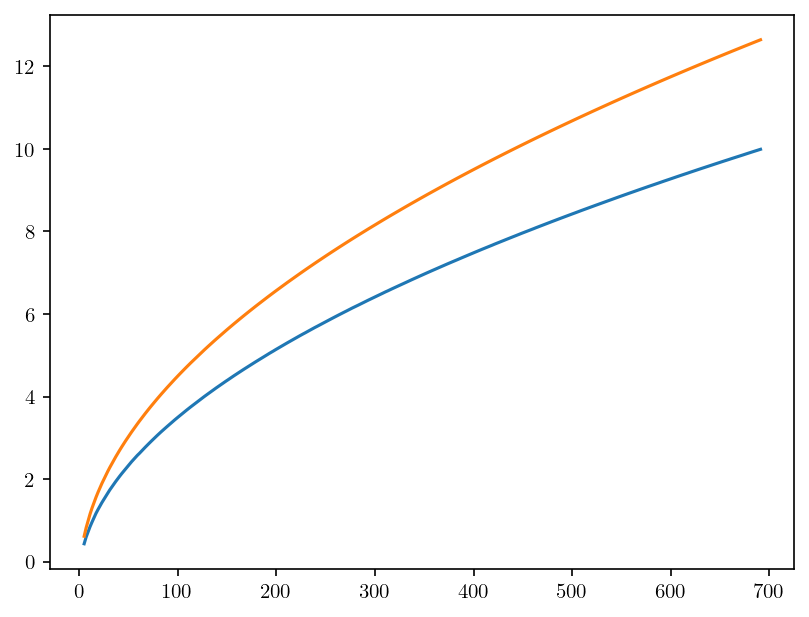

0.5835564186418023 -1.4780350480430913


In [10]:
plt.plot(sizes, mean)
plt.plot(sizes, (np.sqrt(sizes)-1)/2)
plt.show()

x, y = np.polyfit(np.log(sizes), np.log(mean), 1)
print(x, y)

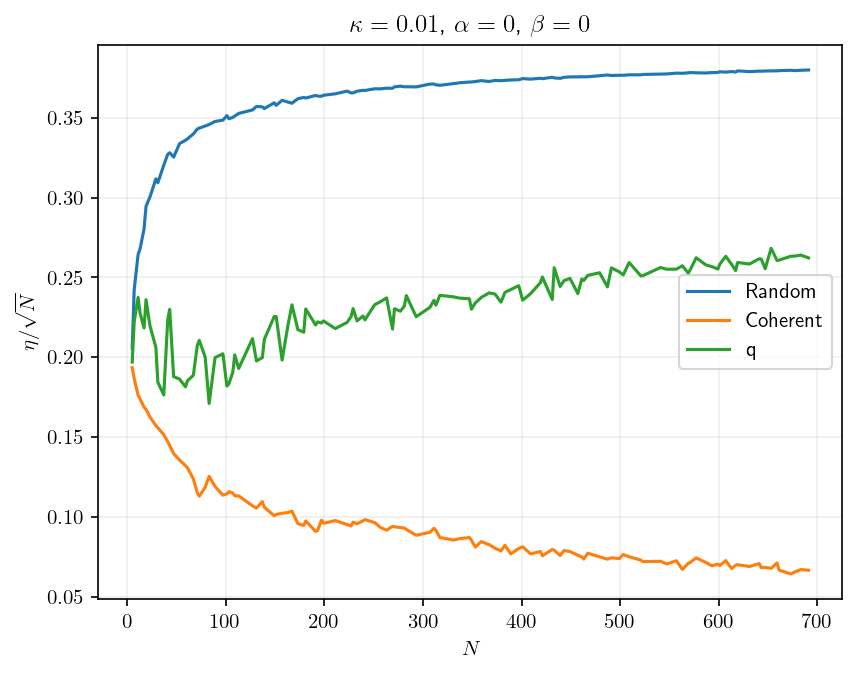

In [8]:
for state, label in zip([random_state, coherent_state, q_eigenstate], ["Random", "Coherent", "q"]):
    neg = system_size_scan(sizes, K1, 0, 0, state, "rotor")
    plt.plot(sizes, neg/np.sqrt(sizes), label = label)
plt.xlabel(rf"$N$")
plt.ylabel(rf"$\eta/\sqrt{{N}}$")
plt.title(rf"$\kappa = {K1}$, $\alpha = 0$, $\beta = 0$")
plt.grid(alpha = 0.2)
plt.legend(loc = 'best')
plt.show()

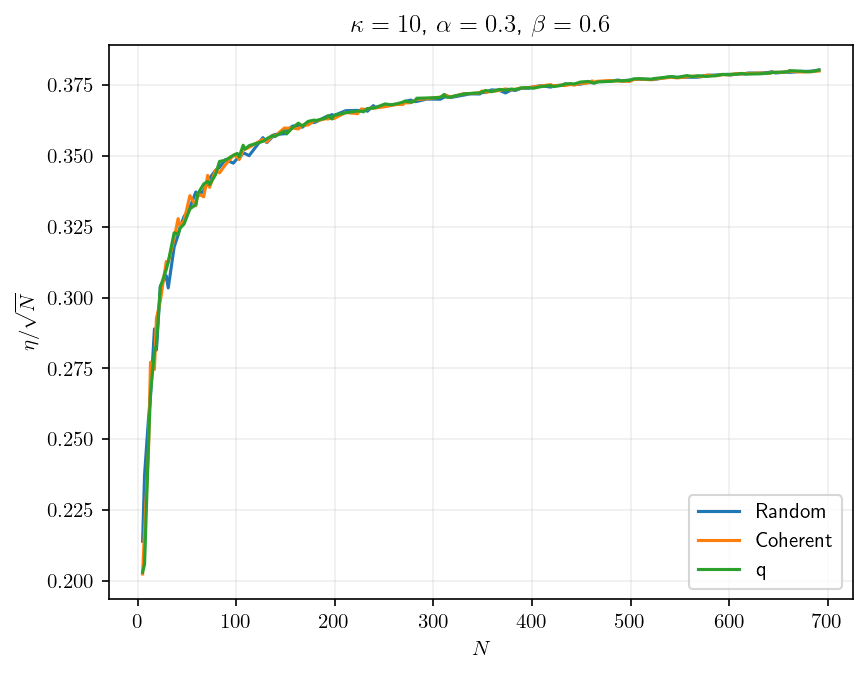

In [9]:
for state, label in zip([random_state, coherent_state, q_eigenstate], ["Random", "Coherent", "q"]):
    neg = system_size_scan(sizes, K3, 0.3, 0.6, state, "rotor")
    plt.plot(sizes, neg/np.sqrt(sizes), label = label)
plt.xlabel(rf"$N$")
plt.ylabel(rf"$\eta/\sqrt{{N}}$")
plt.title(rf"$\kappa = {K3}$, $\alpha = 0.3$, $\beta = 0.6$")
plt.grid(alpha = 0.2)
plt.legend(loc = 'best')
plt.show()

In [5]:
for state, label in zip([random_state, coherent_state, q_eigenstate], ["Random", "Coherent", "q"]):
    neg = system_size_scan(sizes, K1, 0, 0, state, "harper")
    plt.plot(sizes, neg/np.sqrt(sizes), label = label)
plt.xlabel(rf"$N$")
plt.ylabel(rf"$\mathcal{{N}}/\sqrt{{N}}$")
plt.title(rf"$\kappa = {K1}$, $\alpha = 0$, $\beta = 0$")
plt.grid(alpha = 0.2)
plt.legend(loc = 'best')
plt.show()

for state, label in zip([random_state, coherent_state, q_eigenstate], ["Random", "Coherent", "q"]):
    neg = system_size_scan(sizes, K3, 0.3, 0.6, state, "harper")
    plt.plot(sizes, neg/np.sqrt(sizes), label = label)
plt.xlabel(rf"$N$")
plt.ylabel(rf"$\mathcal{{N}}/\sqrt{{N}}$")
plt.title(rf"$\kappa = {K3}$, $\alpha = 0.3$, $\beta = 0.6$")
plt.grid(alpha = 0.2)
plt.legend(loc = 'best')
plt.show()

NameError: name 'sizes' is not defined

In [10]:
# plot the initial negativity for coherent states
neg0 = system_size_scan(sizes, K1, 0, 0, q_eigenstate, "harper")

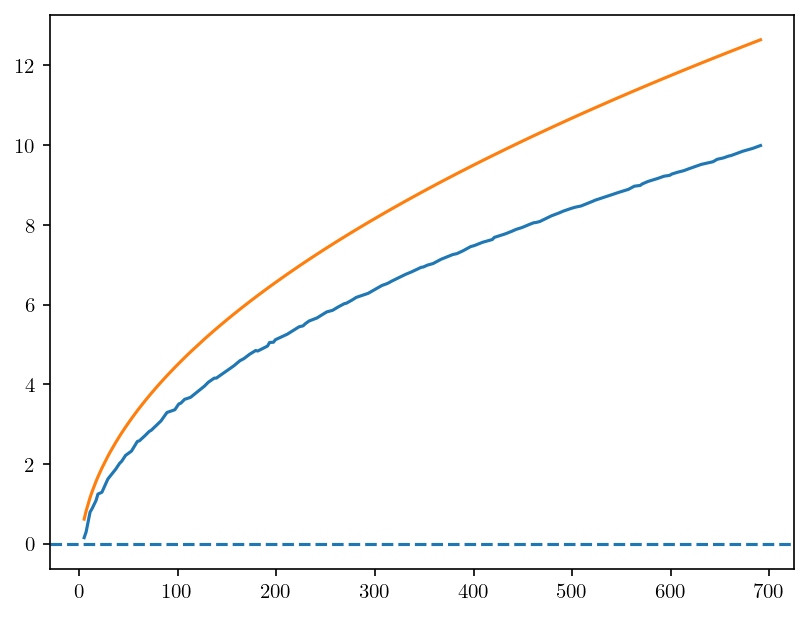

In [11]:
plt.plot(sizes, neg0)
plt.axhline(0, ls = '--')
plt.plot(sizes, (np.sqrt(sizes)-1)/2)
plt.show()

# Initial State is localized randomized state in q-basis

In [4]:
int_neg1_0 = system_size_scan(sizes, K1, 0, 0, localized_state)
int_neg2_0 = system_size_scan(sizes, K2, 0, 0, localized_state)
int_neg3_0 = system_size_scan(sizes, K3, 0, 0, localized_state)

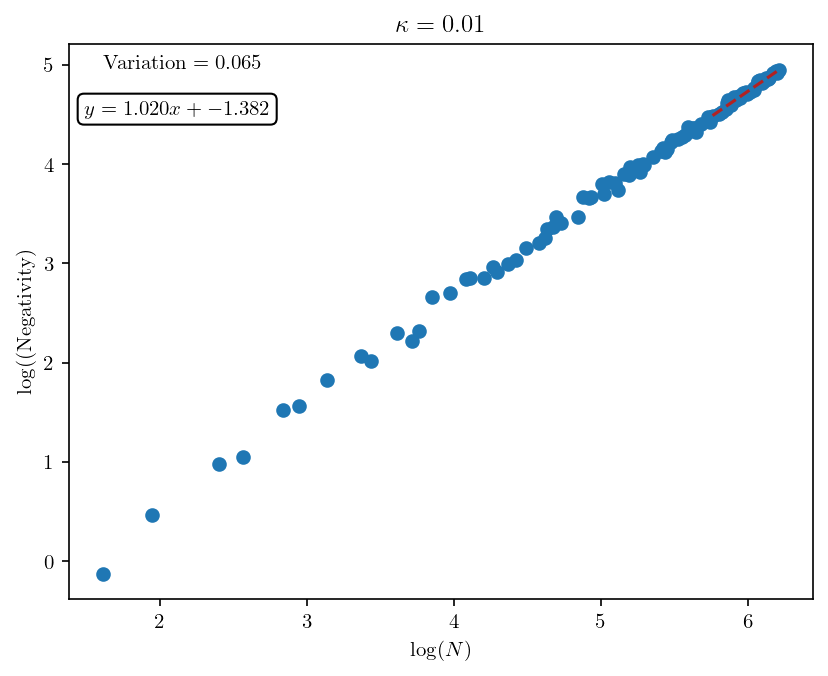

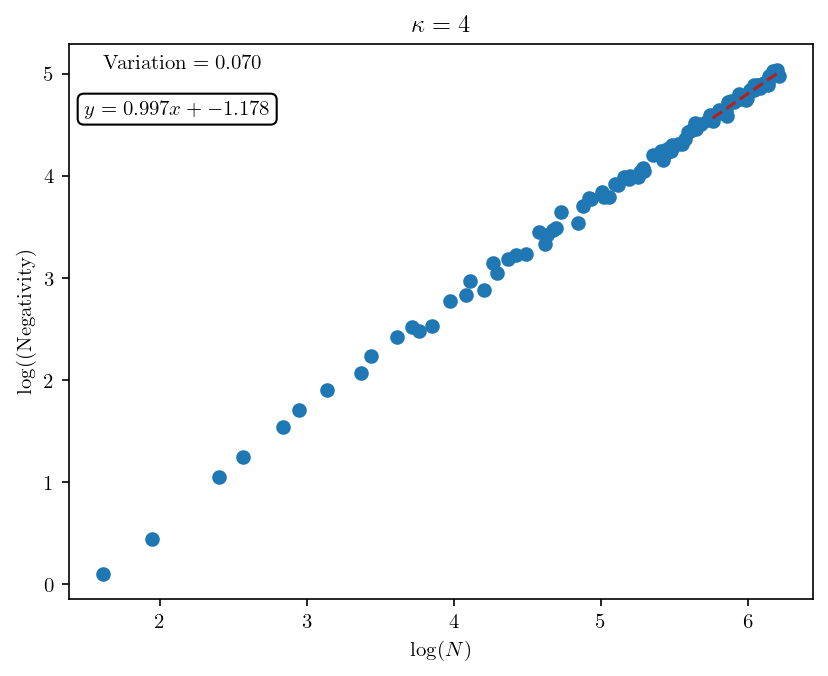

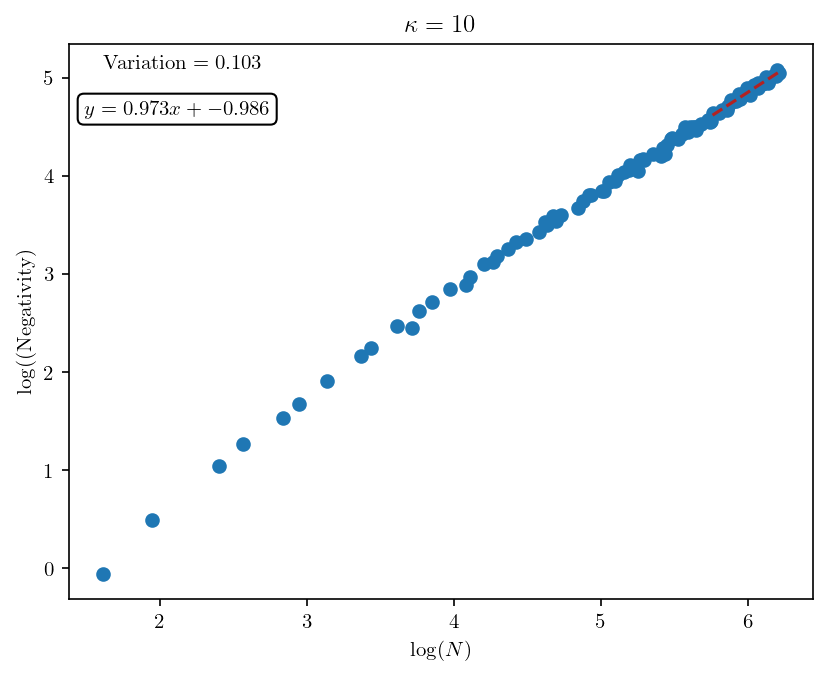

In [5]:
m1, c1 = plot_int_neg(sizes, int_neg1_0, K1)
m2, c2 = plot_int_neg(sizes, int_neg2_0, K2)
m3, c3 = plot_int_neg(sizes, int_neg3_0, K3)

In [6]:
symmetry_params = [(0, 0.5), (0.5, 0), (0.7, 0.4), (0.6, 0), (0, 0.3)]

sym pars:   0%|          | 0/5 [00:00<?, ?it/s]

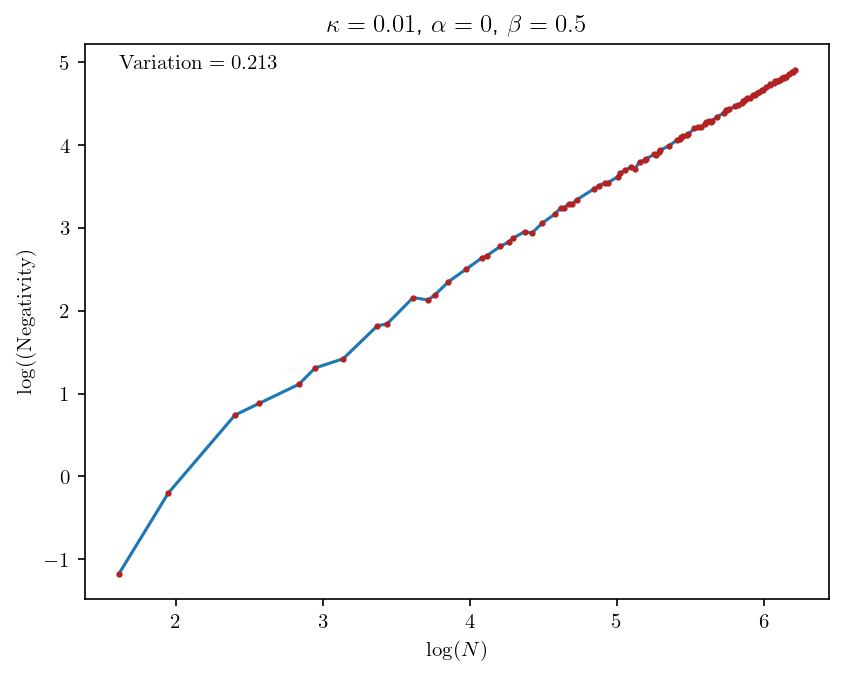

sym pars:  20%|██        | 1/5 [00:01<00:07,  1.84s/it]

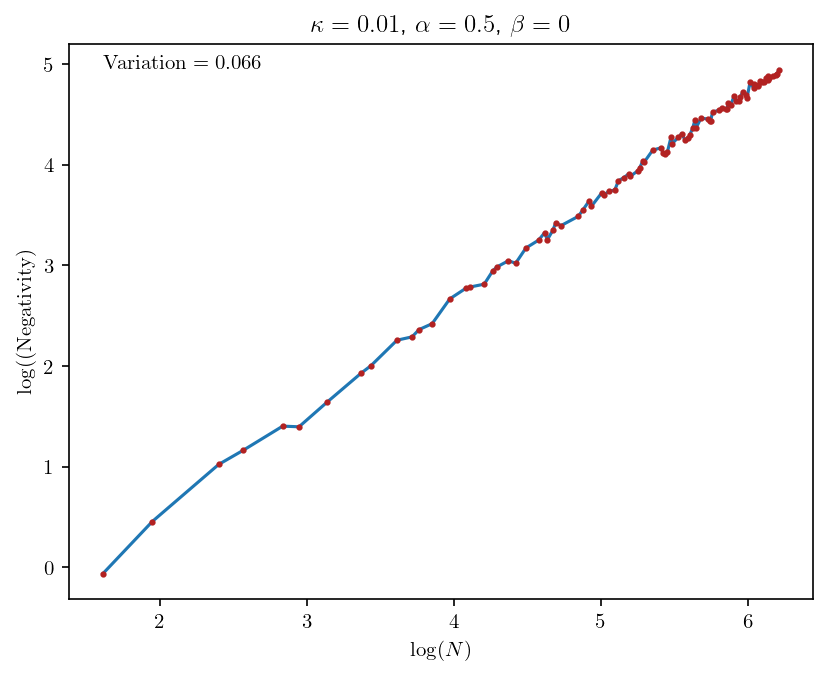

sym pars:  40%|████      | 2/5 [00:03<00:04,  1.54s/it]

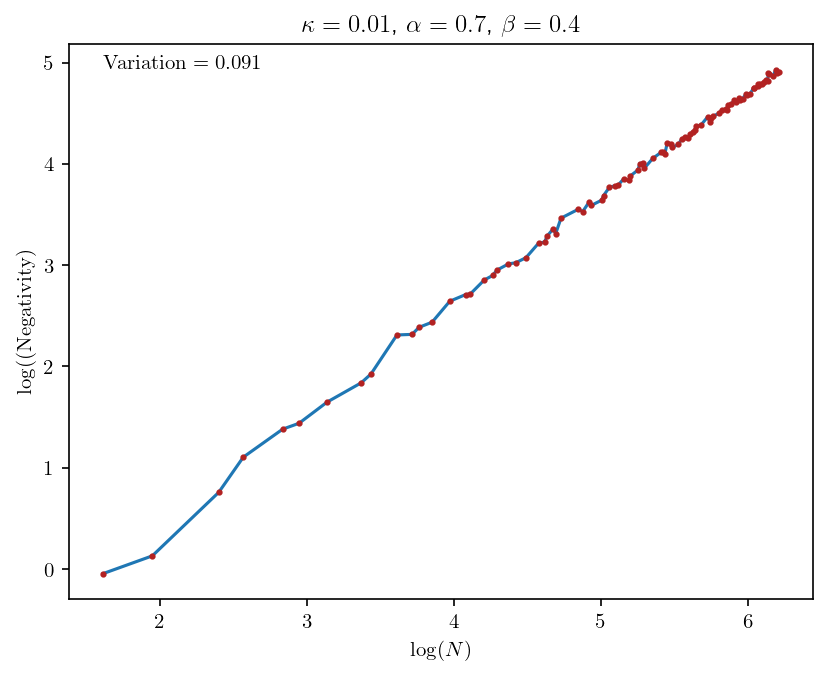

sym pars:  60%|██████    | 3/5 [00:04<00:02,  1.45s/it]

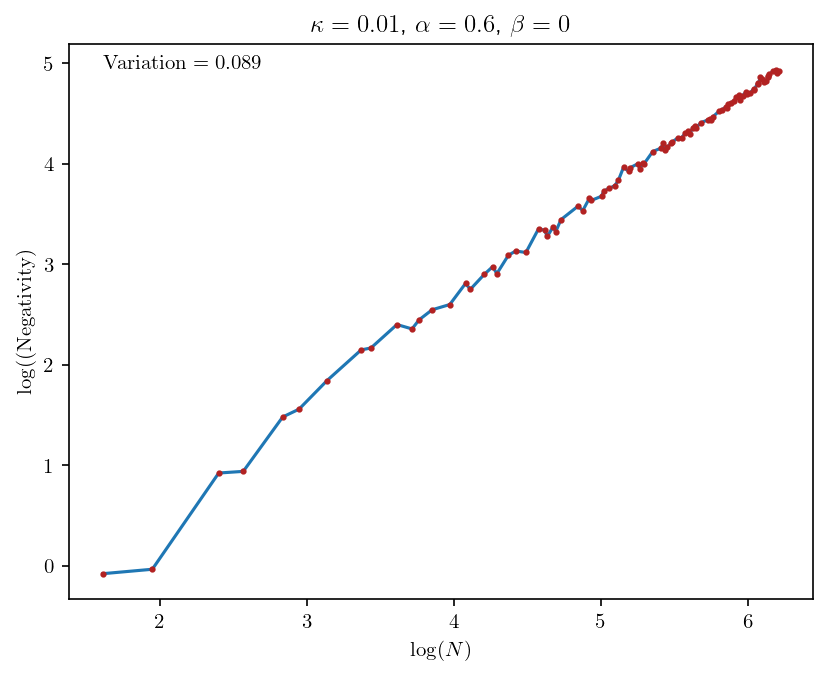

sym pars:  80%|████████  | 4/5 [00:05<00:01,  1.41s/it]

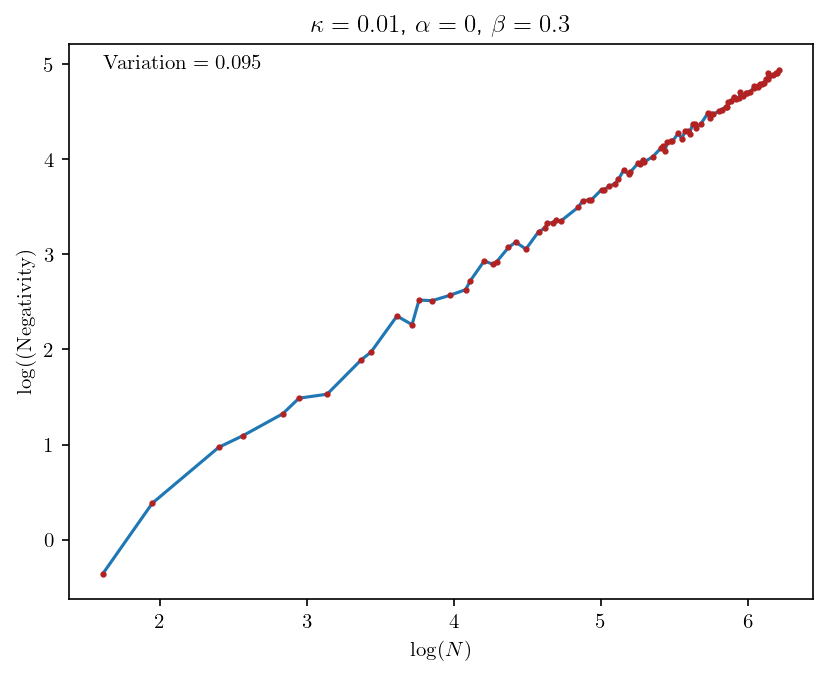

sym pars:   0%|          | 0/5 [00:00<?, ?it/s]        

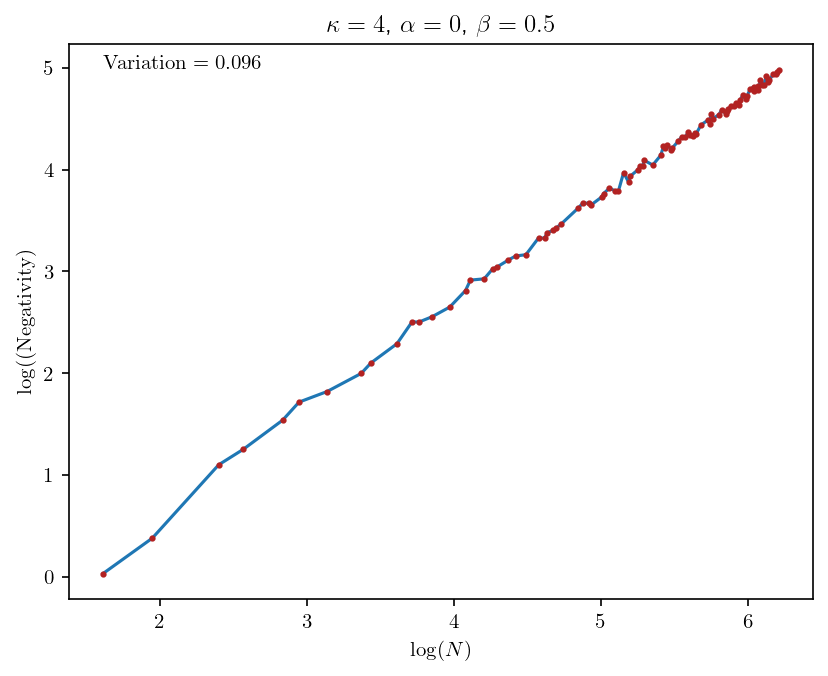

sym pars:  20%|██        | 1/5 [00:01<00:05,  1.35s/it]

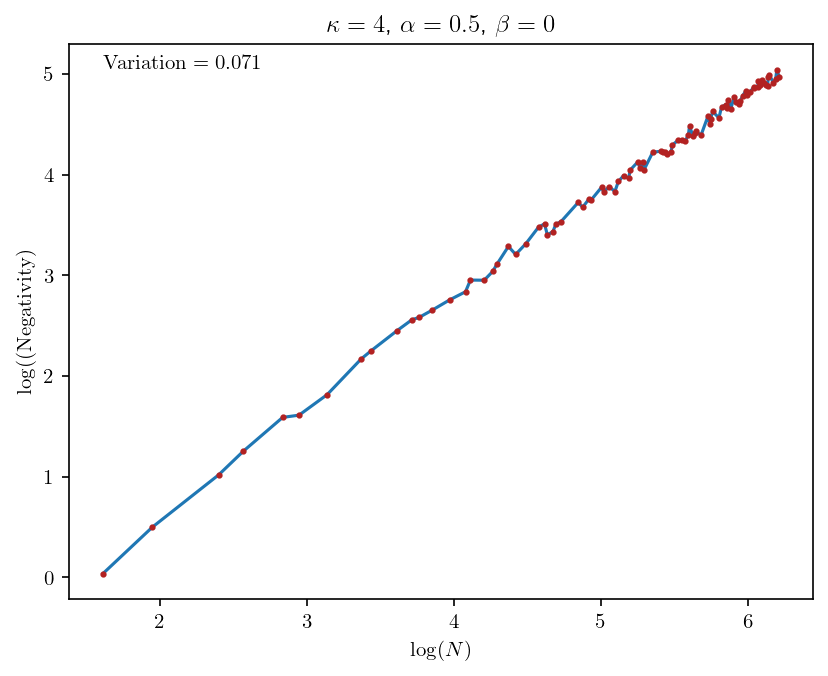

sym pars:  40%|████      | 2/5 [00:02<00:03,  1.32s/it]

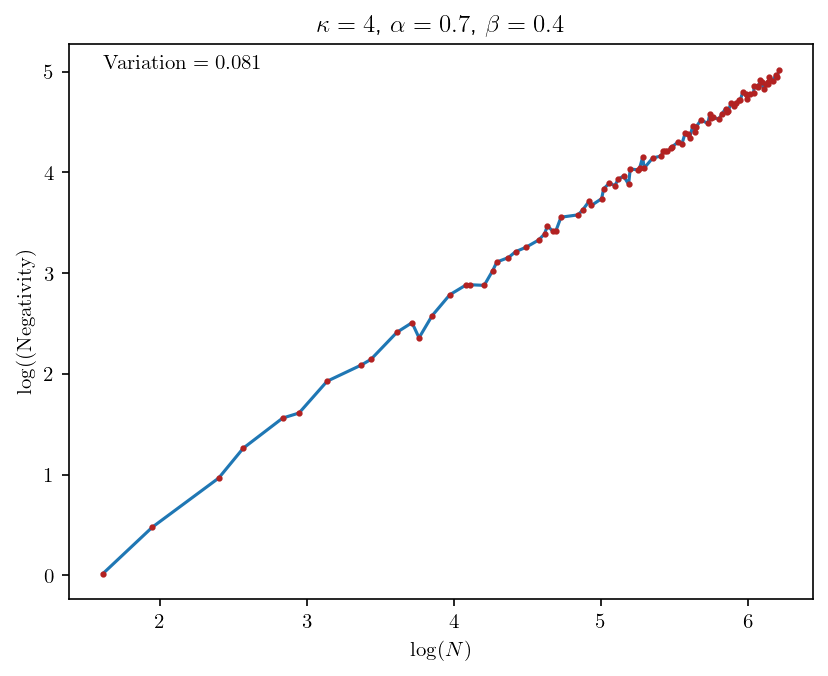

sym pars:  60%|██████    | 3/5 [00:04<00:02,  1.37s/it]

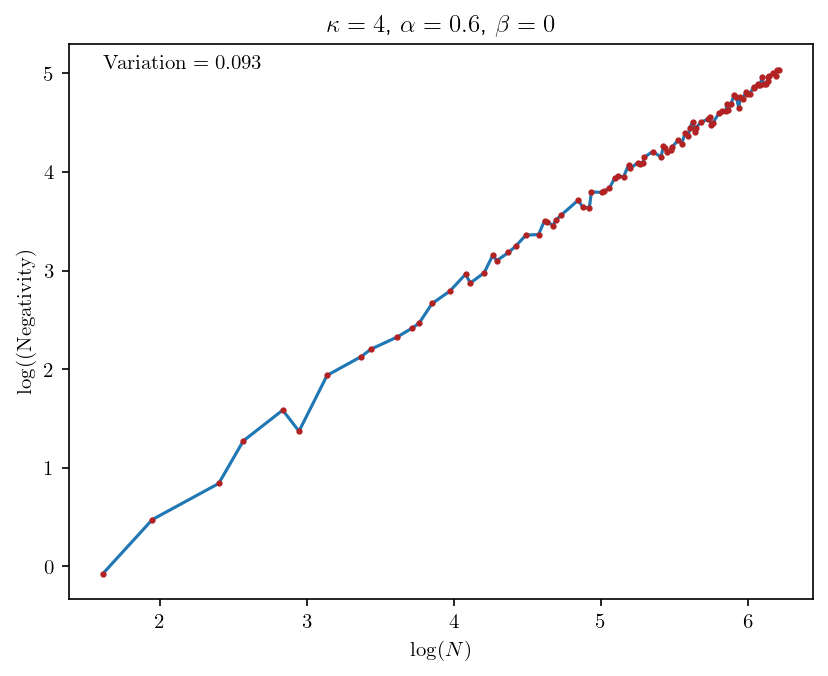

sym pars:  80%|████████  | 4/5 [00:05<00:01,  1.35s/it]

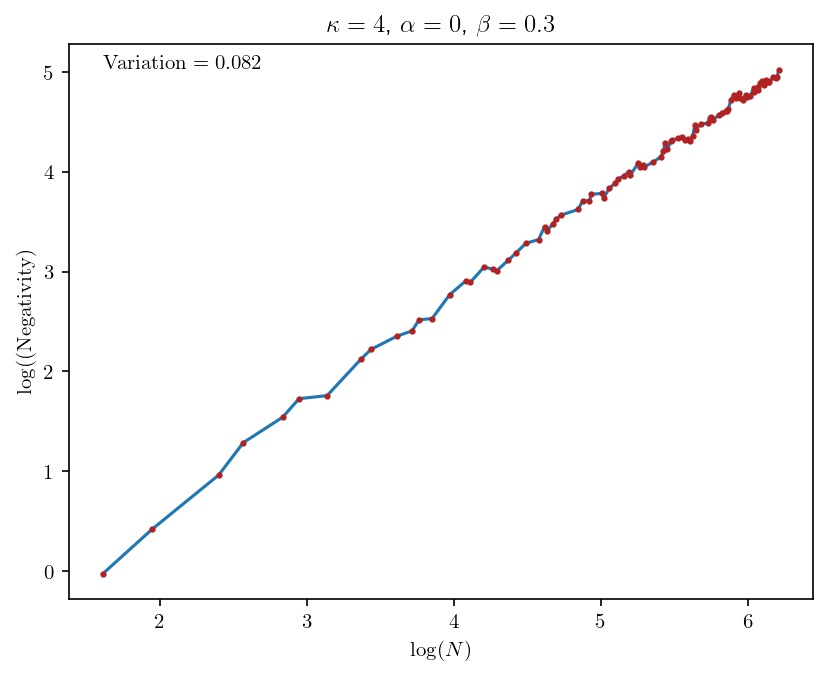

sym pars:   0%|          | 0/5 [00:00<?, ?it/s]        

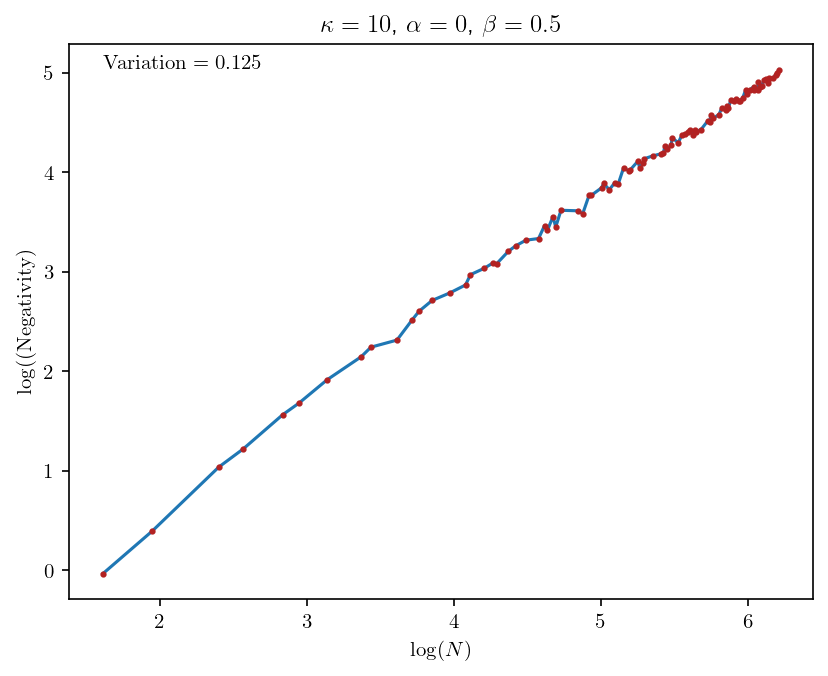

sym pars:  20%|██        | 1/5 [00:01<00:07,  1.81s/it]

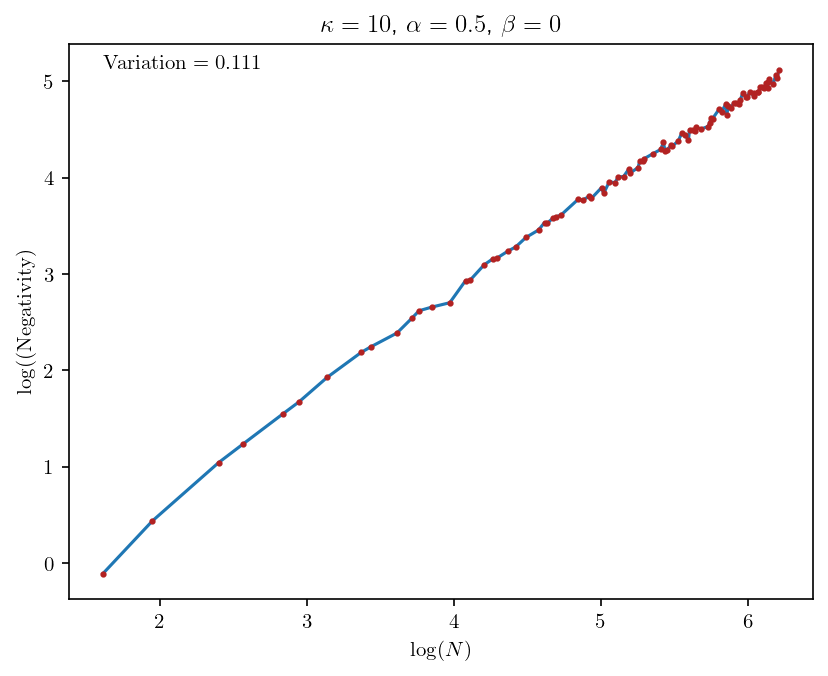

sym pars:  40%|████      | 2/5 [00:03<00:04,  1.52s/it]

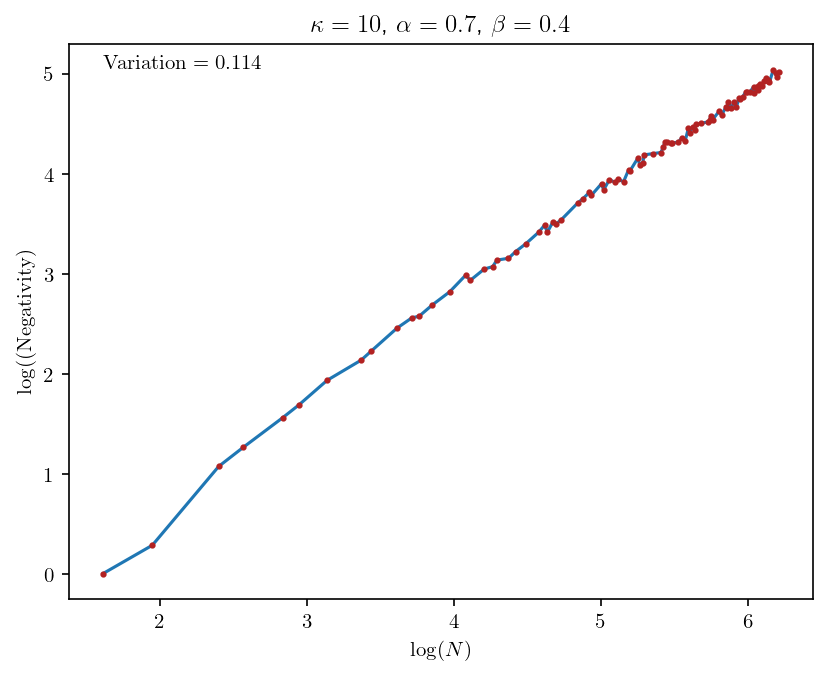

sym pars:  60%|██████    | 3/5 [00:04<00:03,  1.55s/it]

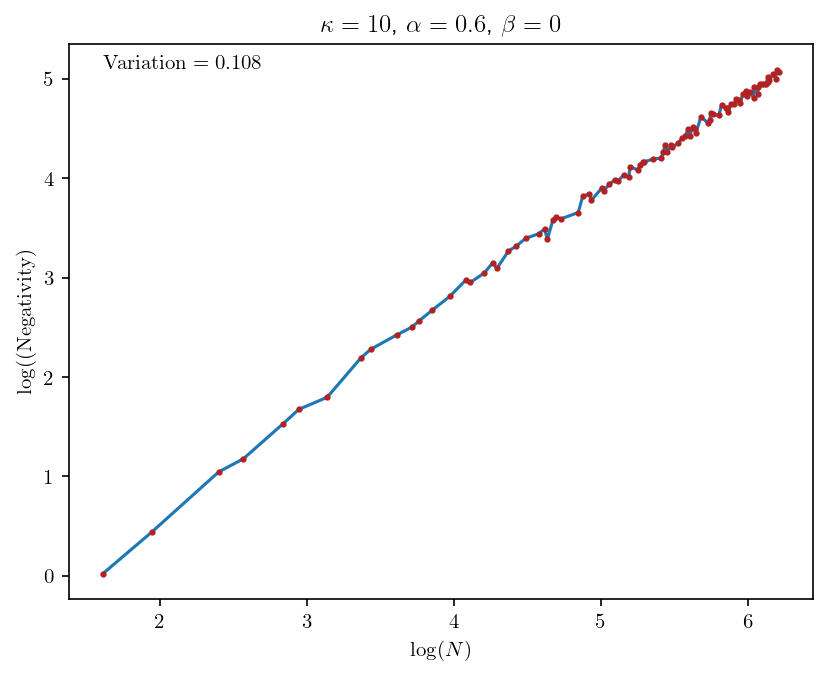

sym pars:  80%|████████  | 4/5 [00:06<00:01,  1.56s/it]

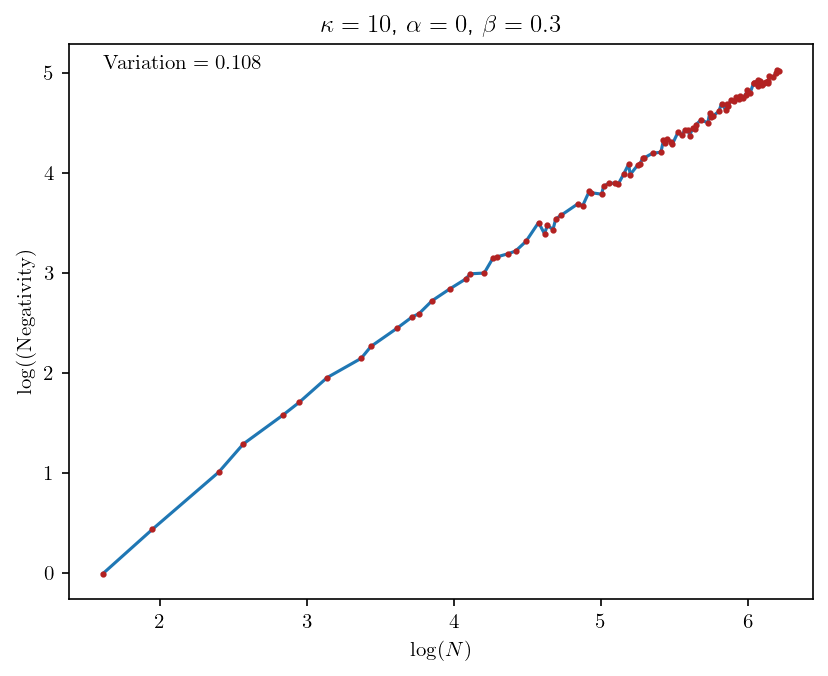

In [7]:
analyze(sizes, K1, symmetry_params, m1, c1, localized_state)
analyze(sizes, K2, symmetry_params, m2, c2, localized_state)
analyze(sizes, K3, symmetry_params, m3, c3, localized_state)

# Initial state for this is the q-eigenstate

In [8]:
neg_q1 = system_size_scan(sizes, K1, 0, 0, q_eigenstate)
neg_q2 = system_size_scan(sizes, K2, 0, 0, q_eigenstate)
neg_q3 = system_size_scan(sizes, K3, 0, 0, q_eigenstate)

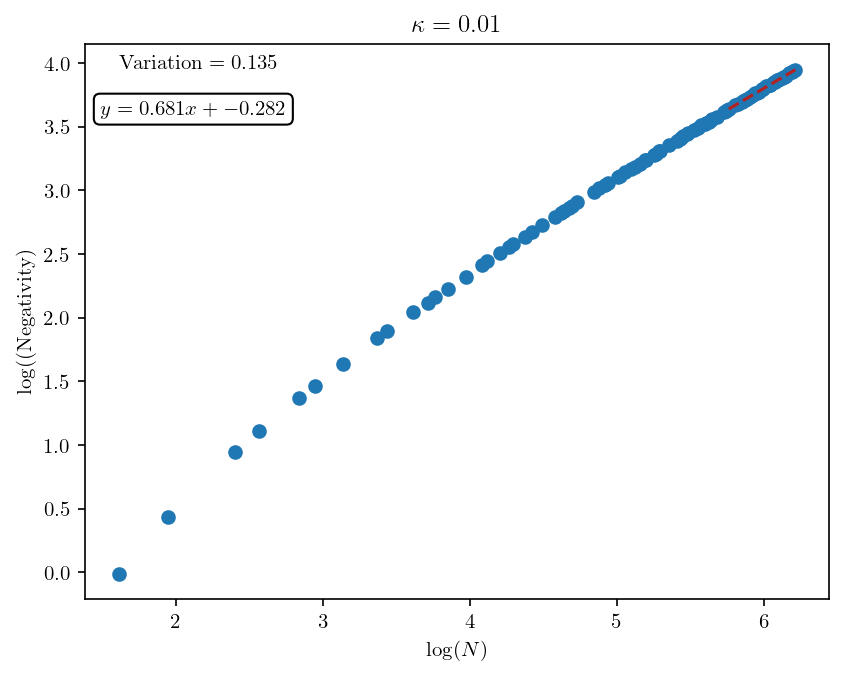

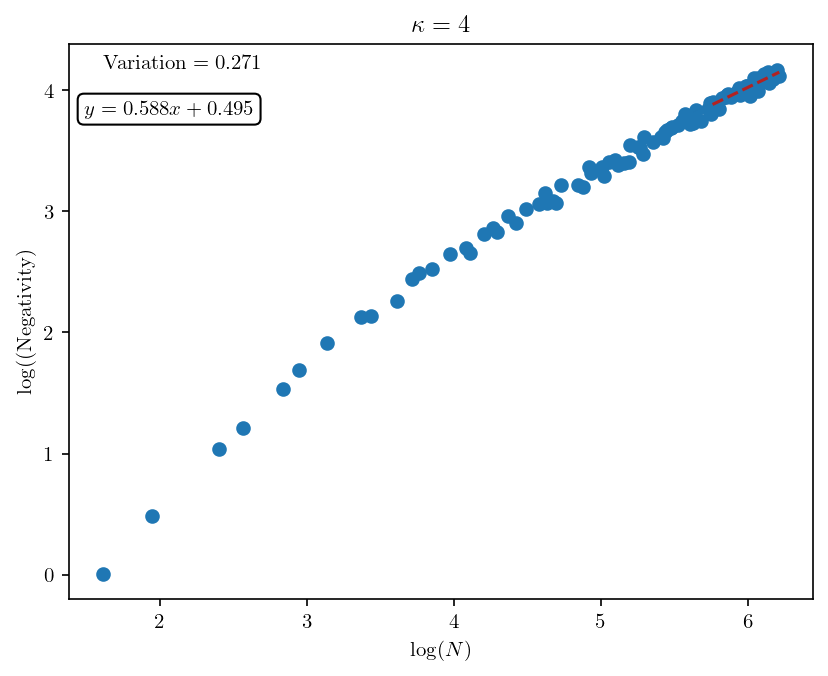

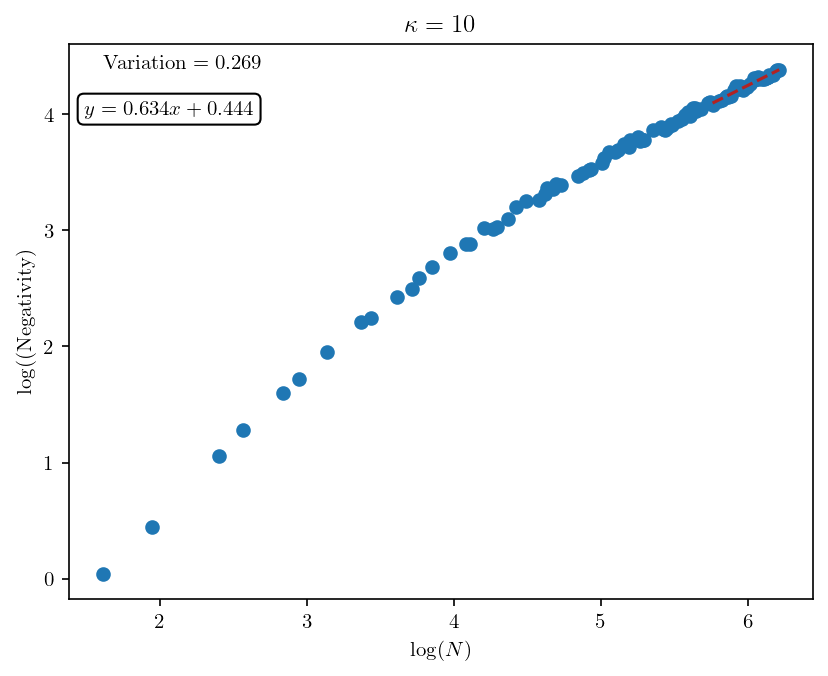

In [9]:
m1, c1 = plot_int_neg(sizes, neg_q1, K1)
m2, c2 = plot_int_neg(sizes, neg_q2, K2)
m3, c3 = plot_int_neg(sizes, neg_q3, K3)

sym pars:   0%|          | 0/5 [00:00<?, ?it/s]

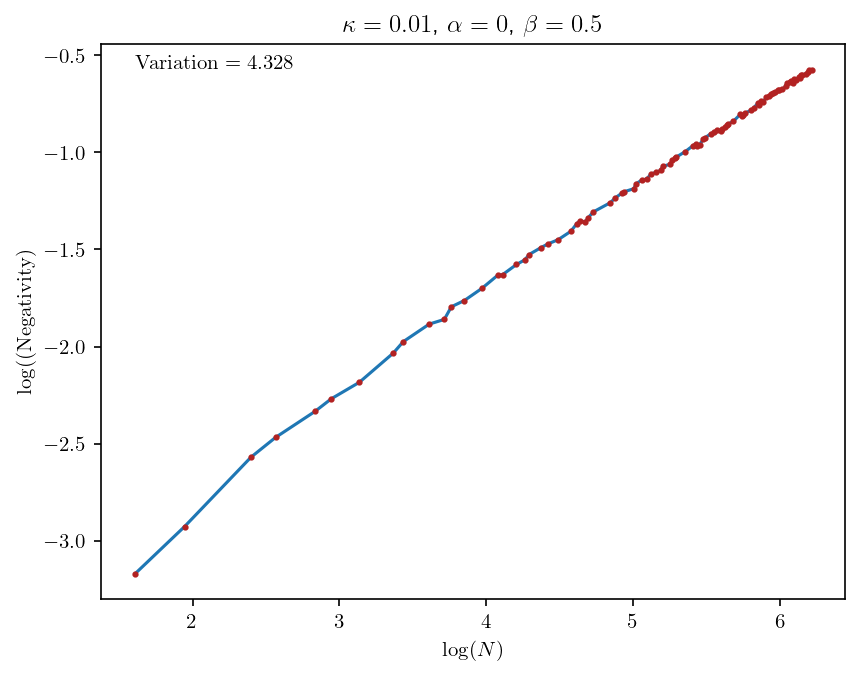

sym pars:  20%|██        | 1/5 [00:01<00:07,  1.98s/it]

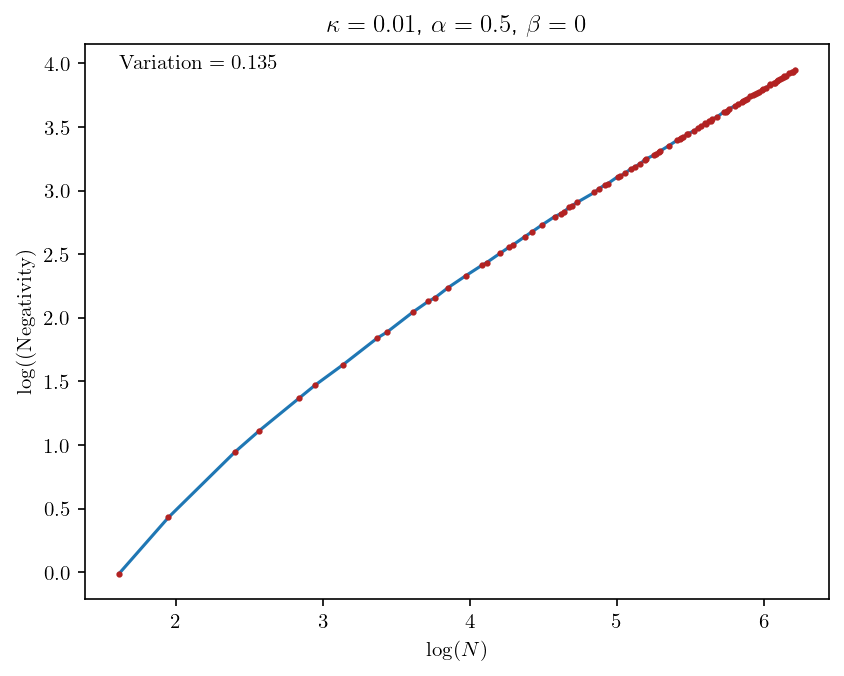

sym pars:  40%|████      | 2/5 [00:03<00:05,  1.80s/it]

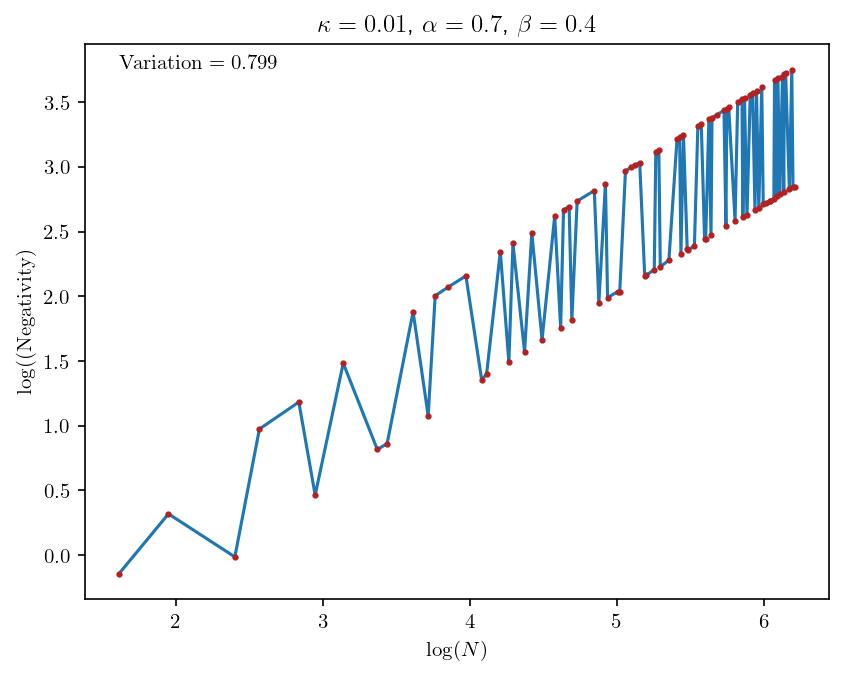

sym pars:  60%|██████    | 3/5 [00:06<00:04,  2.10s/it]

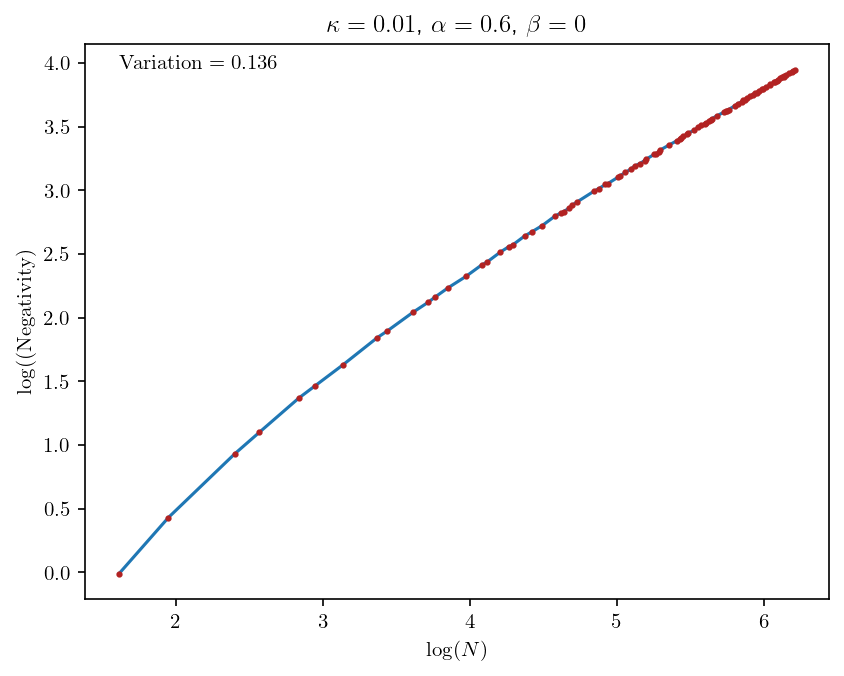

sym pars:  80%|████████  | 4/5 [00:08<00:02,  2.03s/it]

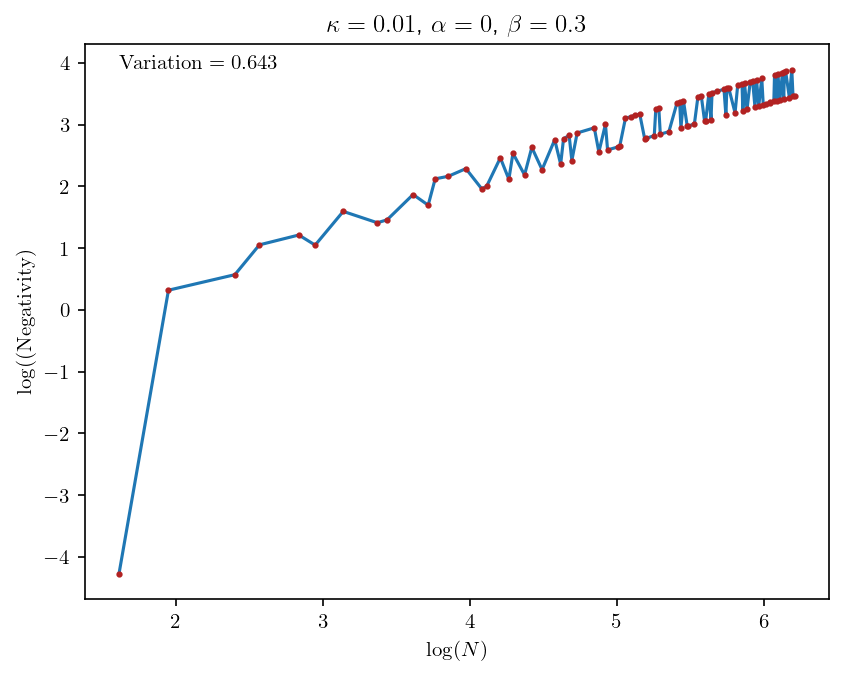

sym pars:   0%|          | 0/5 [00:00<?, ?it/s]        

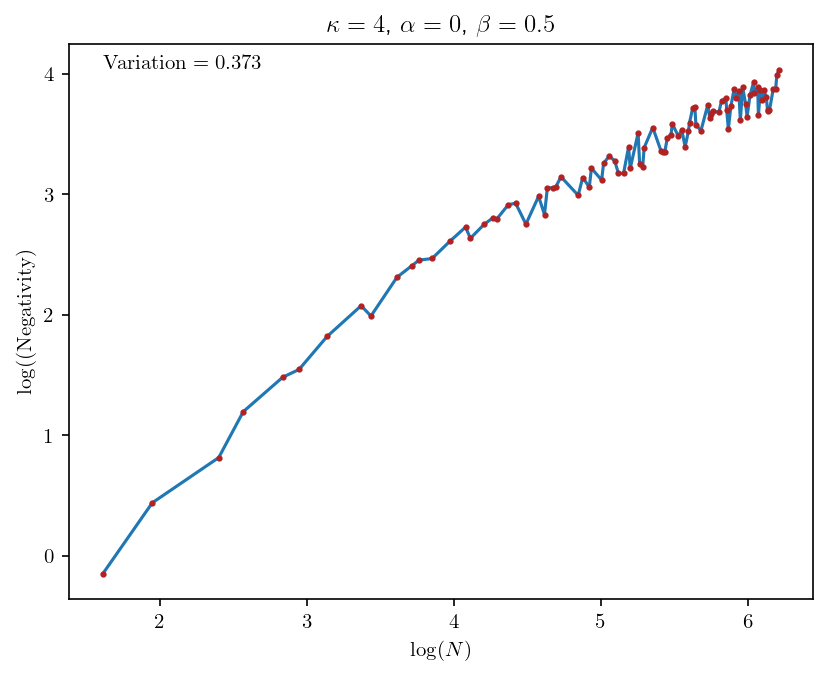

sym pars:  20%|██        | 1/5 [00:02<00:09,  2.49s/it]

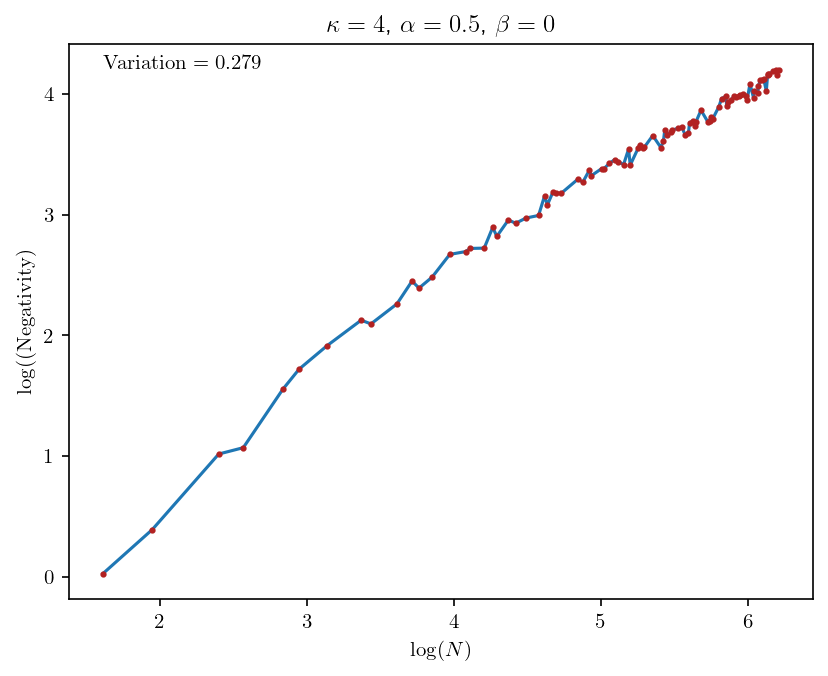

sym pars:  40%|████      | 2/5 [00:04<00:07,  2.42s/it]

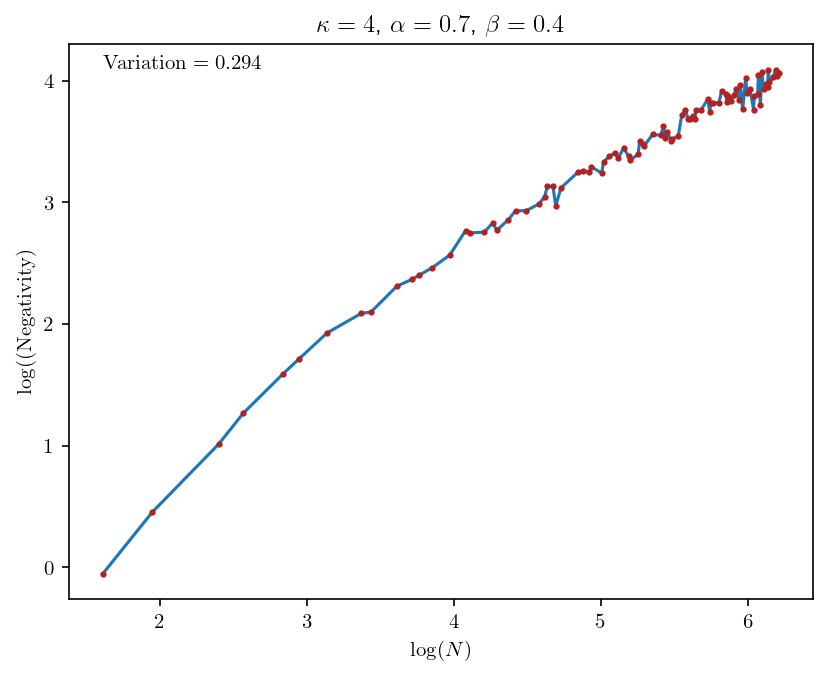

sym pars:  60%|██████    | 3/5 [00:07<00:04,  2.45s/it]

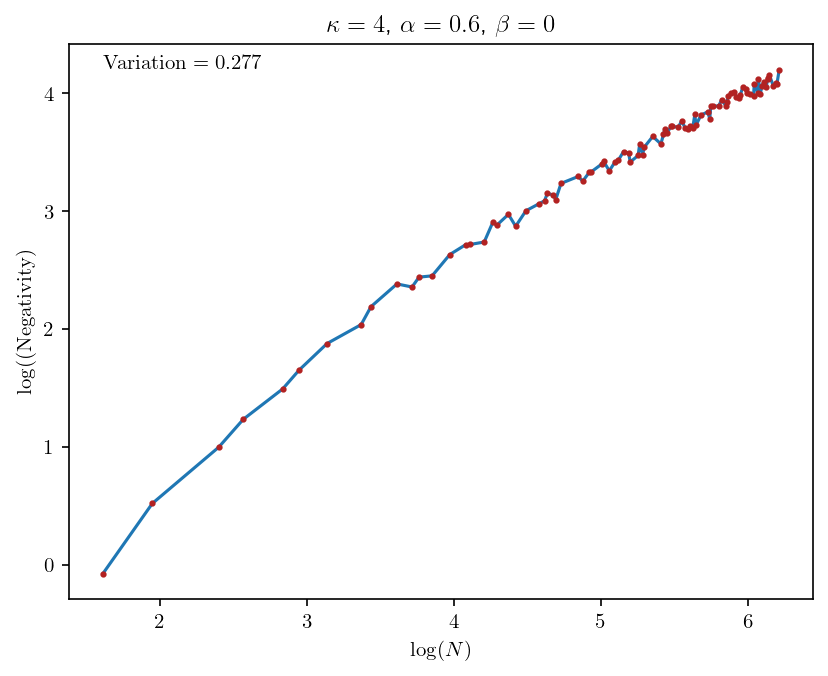

sym pars:  80%|████████  | 4/5 [00:09<00:02,  2.45s/it]

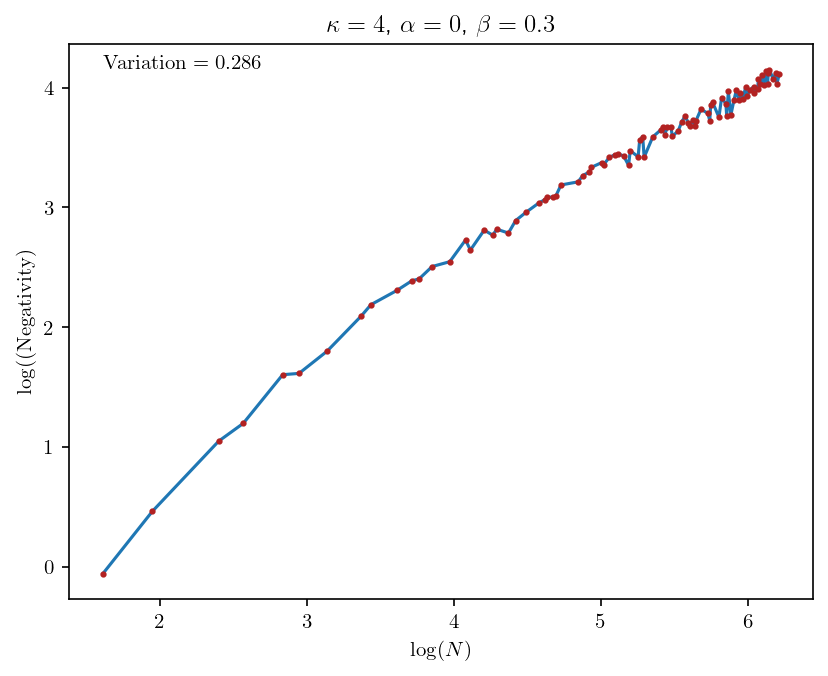

sym pars:   0%|          | 0/5 [00:00<?, ?it/s]        

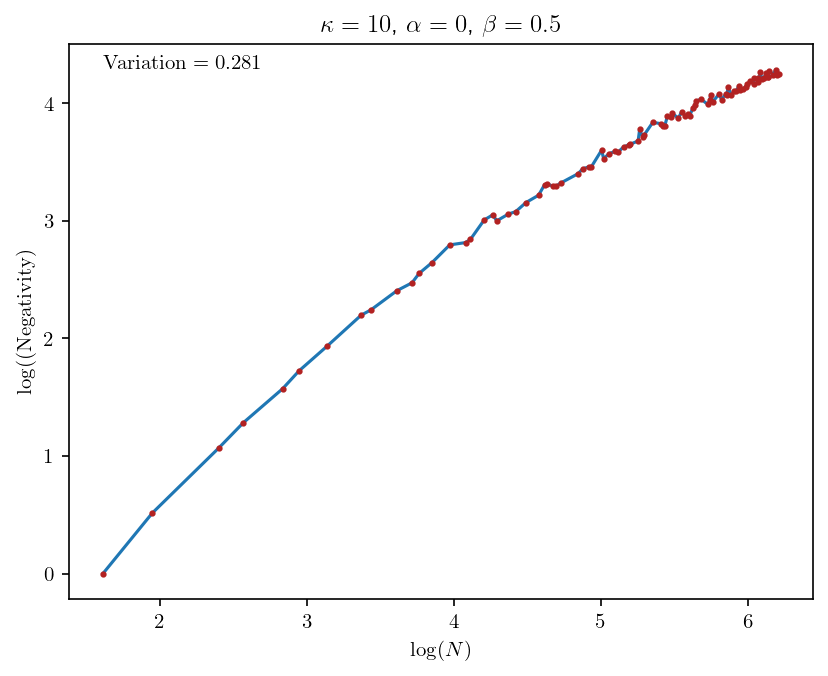

sym pars:  20%|██        | 1/5 [00:02<00:09,  2.36s/it]

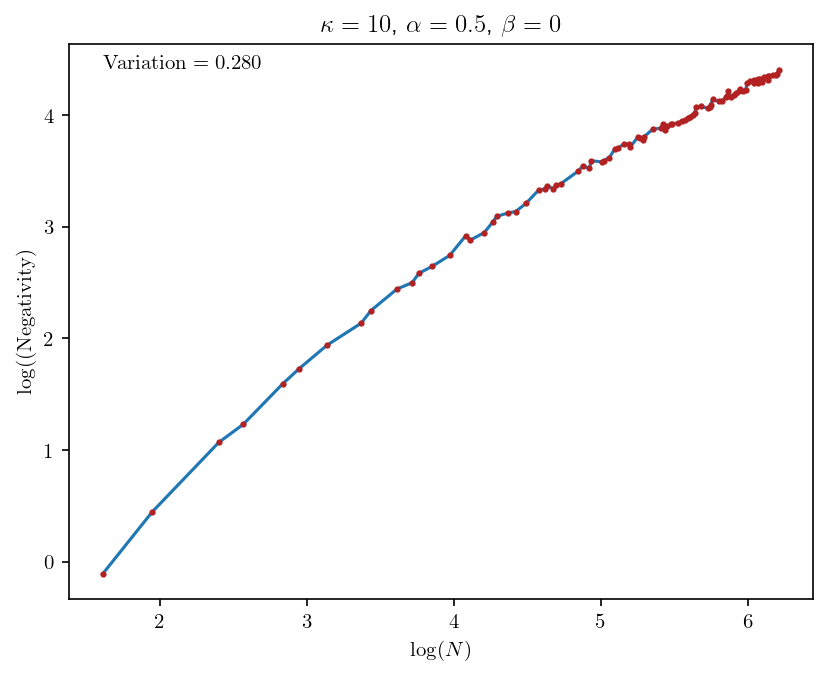

sym pars:  40%|████      | 2/5 [00:04<00:07,  2.43s/it]

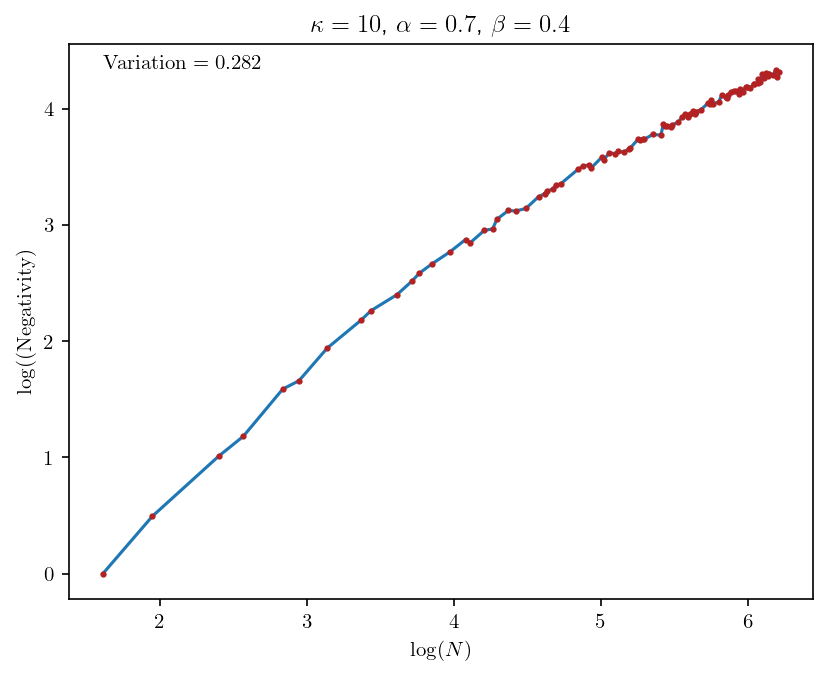

sym pars:  60%|██████    | 3/5 [00:07<00:04,  2.45s/it]

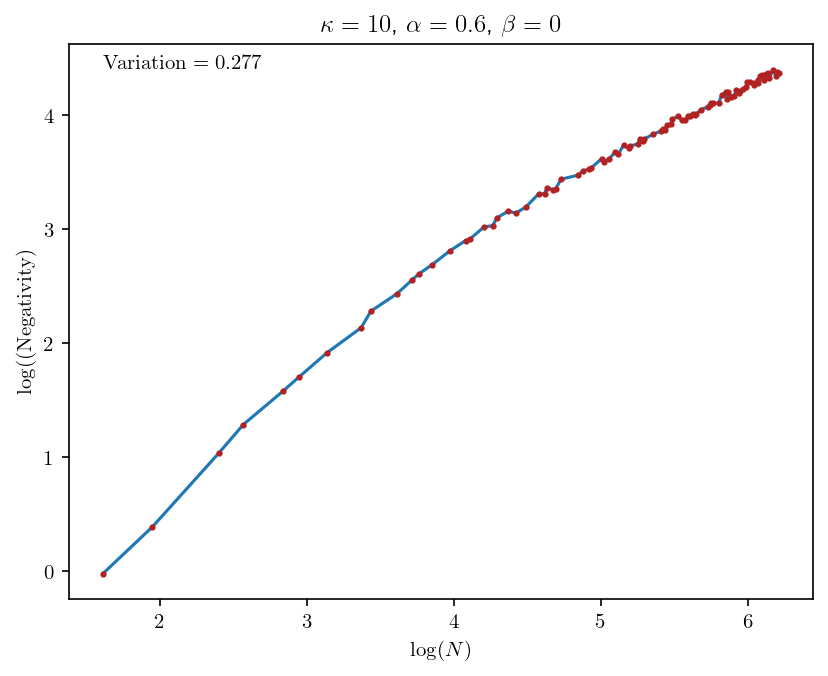

sym pars:  80%|████████  | 4/5 [00:09<00:02,  2.22s/it]

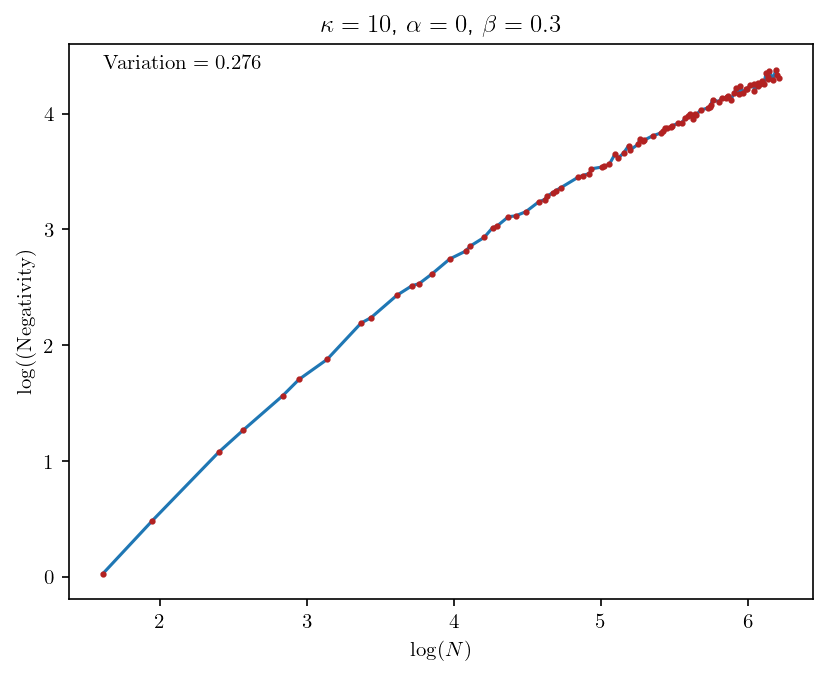

In [10]:
analyze(sizes, K1, symmetry_params, m1, c1, q_eigenstate)
analyze(sizes, K2, symmetry_params, m2, c2, q_eigenstate)
analyze(sizes, K3, symmetry_params, m3, c3, q_eigenstate)

# Completely random initial_state

In [11]:
neg_rand1 = system_size_scan(sizes, K1, 0, 0, random_state)
neg_rand2 = system_size_scan(sizes, K2, 0, 0, random_state)
neg_rand3 = system_size_scan(sizes, K3, 0, 0, random_state)

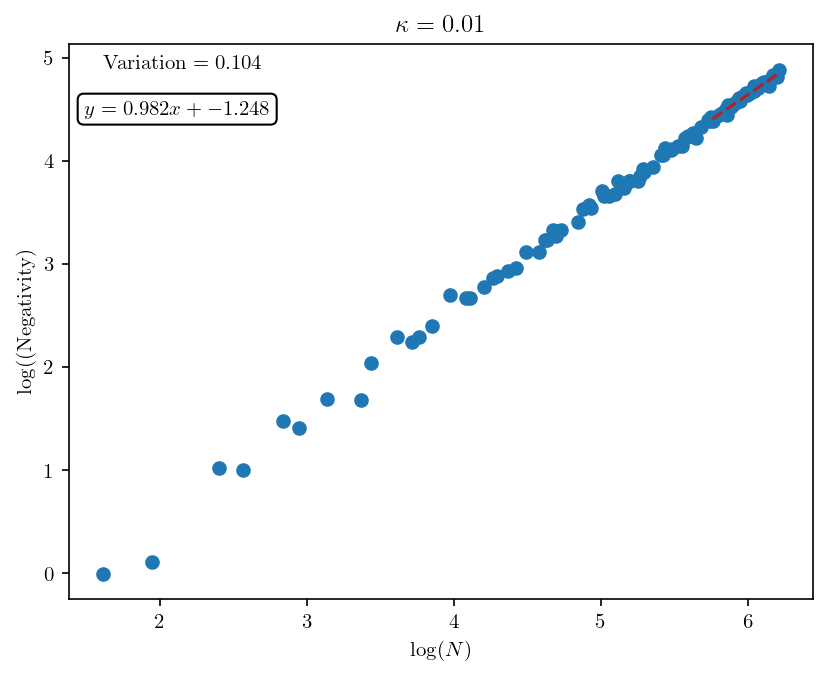

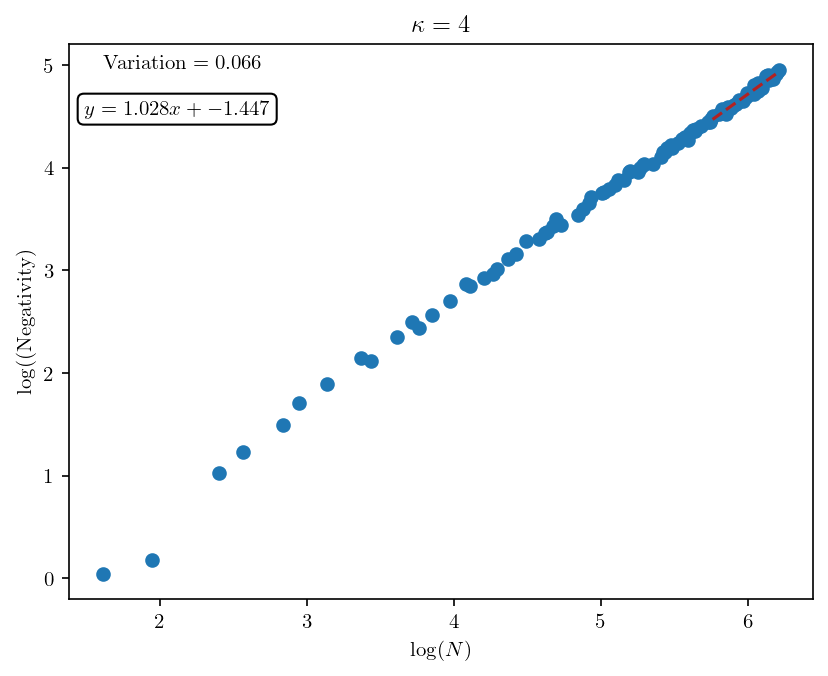

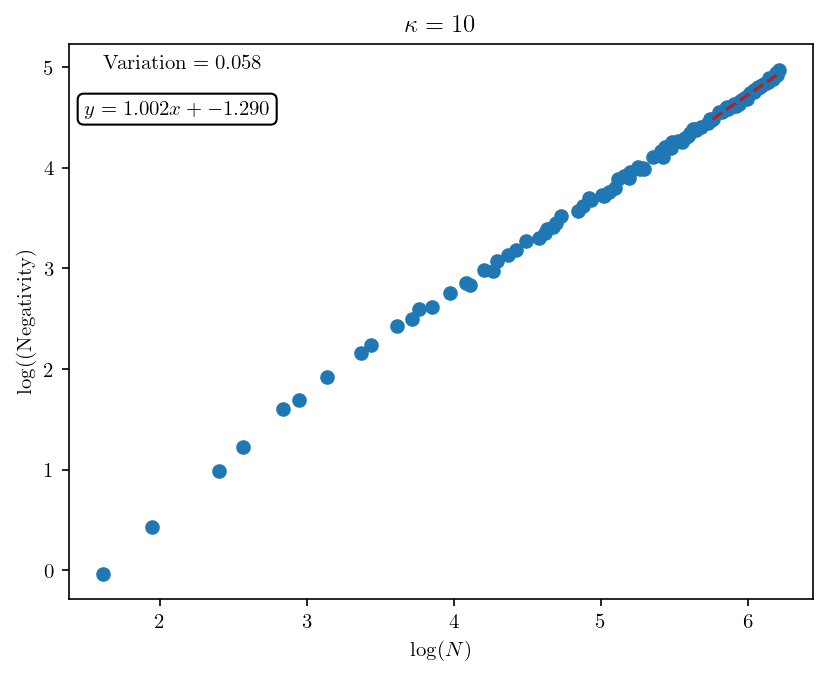

In [12]:
m1, c1 = plot_int_neg(sizes, neg_rand1, K1)
m2, c2 = plot_int_neg(sizes, neg_rand2, K2)
m3, c3 = plot_int_neg(sizes, neg_rand3, K3)

sym pars:   0%|          | 0/5 [00:00<?, ?it/s]

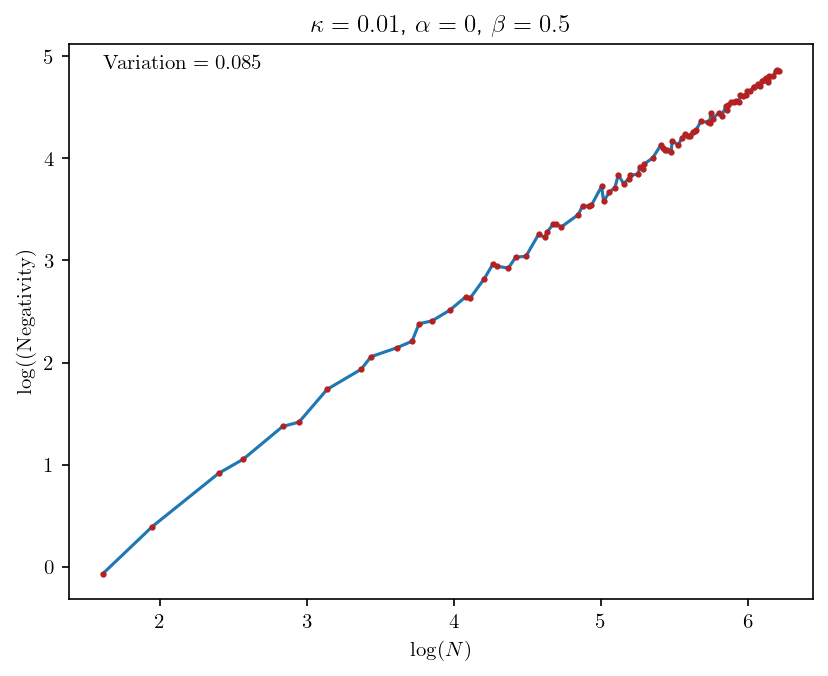

sym pars:  20%|██        | 1/5 [00:02<00:08,  2.09s/it]

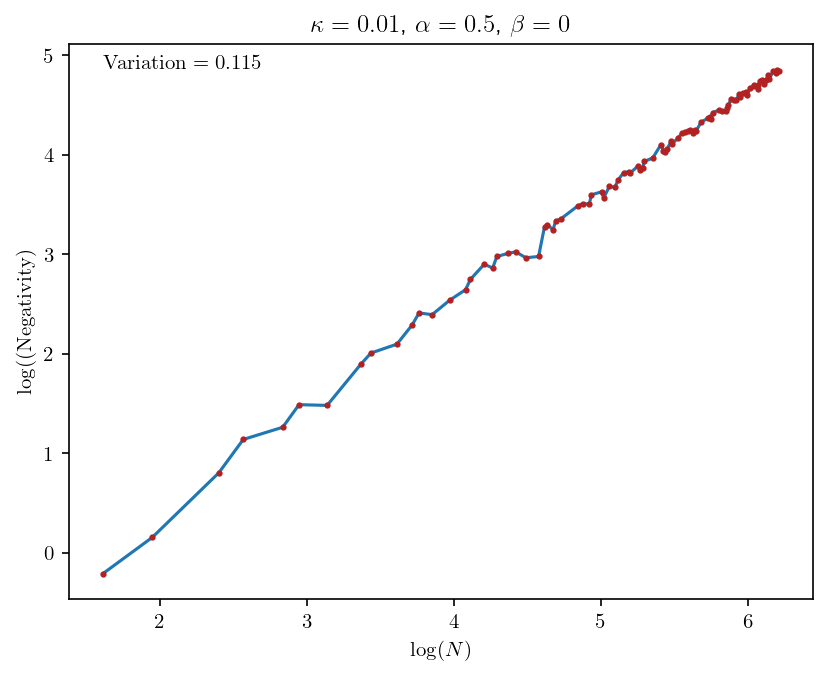

sym pars:  40%|████      | 2/5 [00:03<00:05,  1.91s/it]

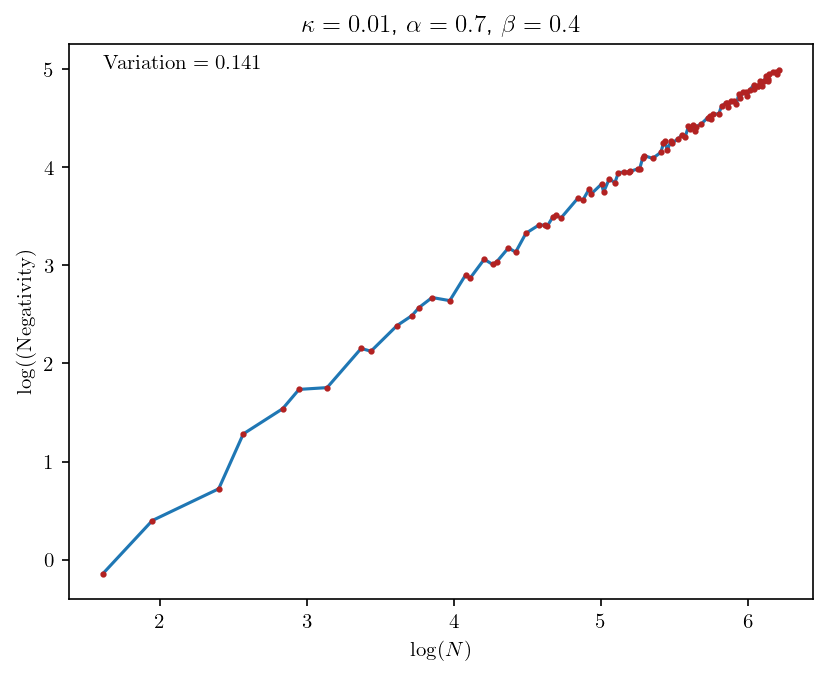

sym pars:  60%|██████    | 3/5 [00:05<00:03,  1.98s/it]

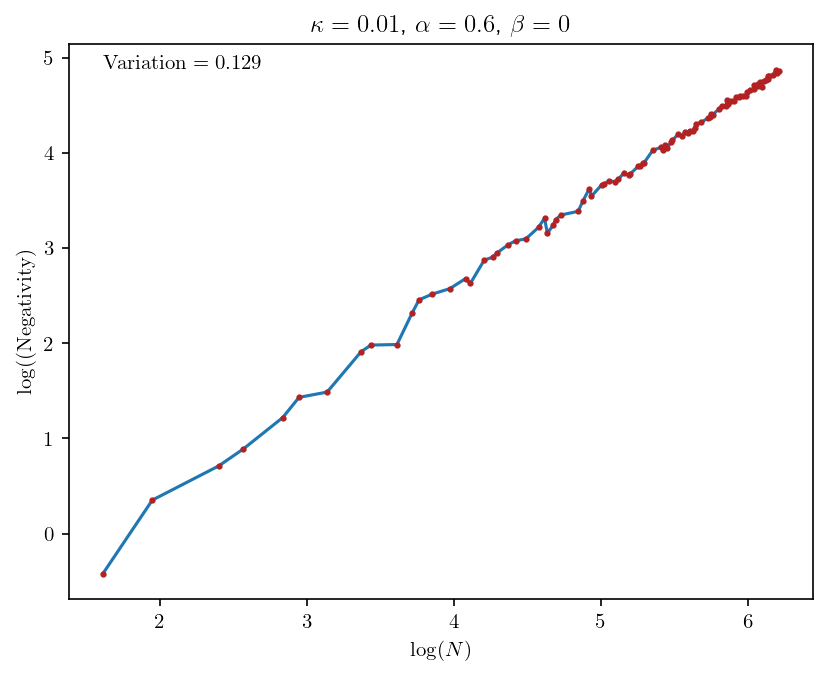

sym pars:  80%|████████  | 4/5 [00:07<00:01,  1.96s/it]

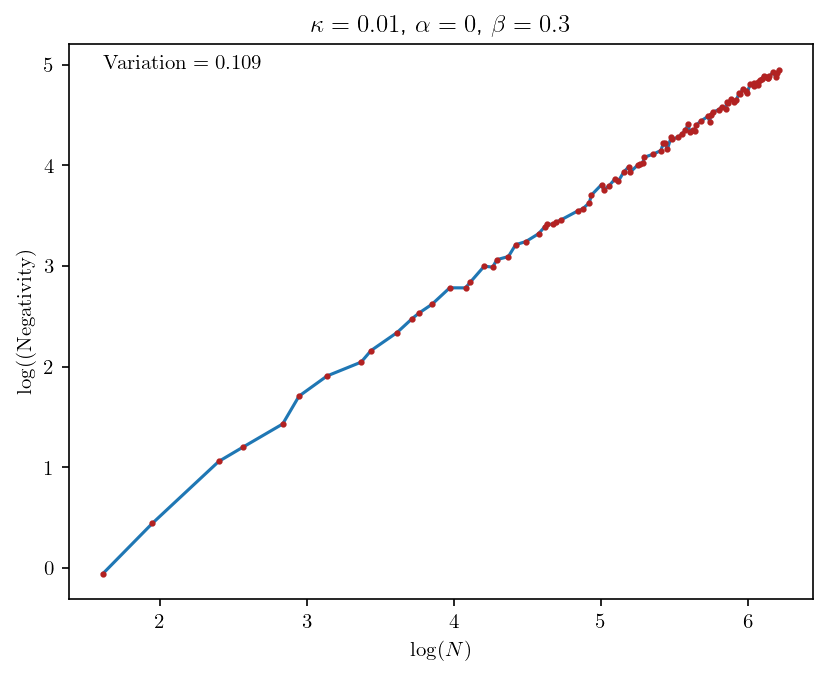

sym pars:   0%|          | 0/5 [00:00<?, ?it/s]        

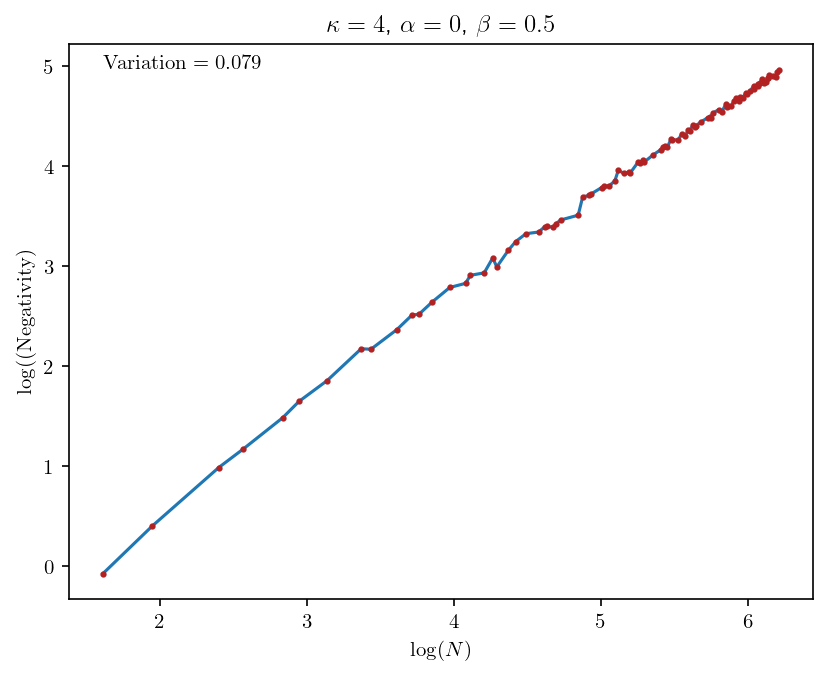

sym pars:  20%|██        | 1/5 [00:01<00:07,  1.99s/it]

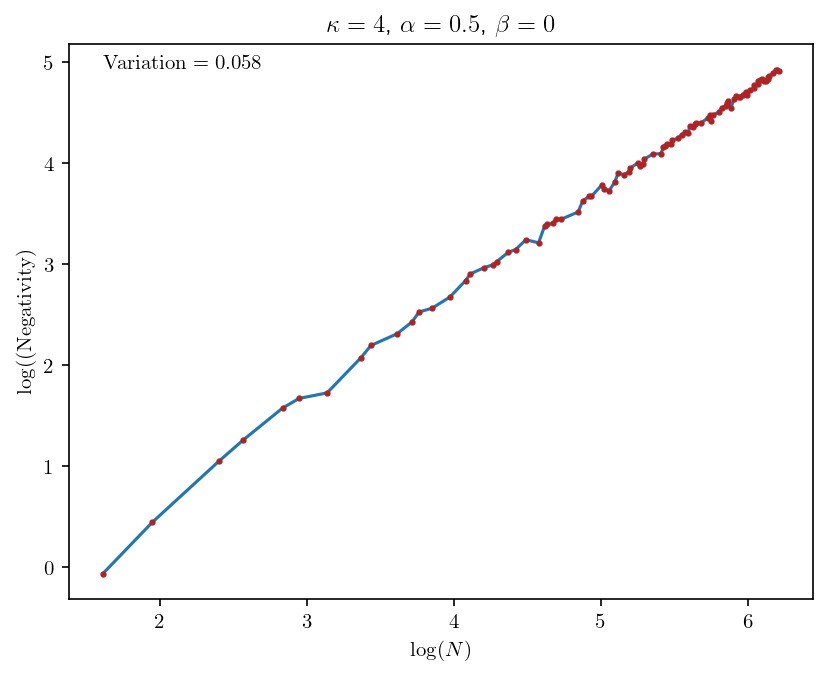

sym pars:  40%|████      | 2/5 [00:03<00:05,  1.96s/it]

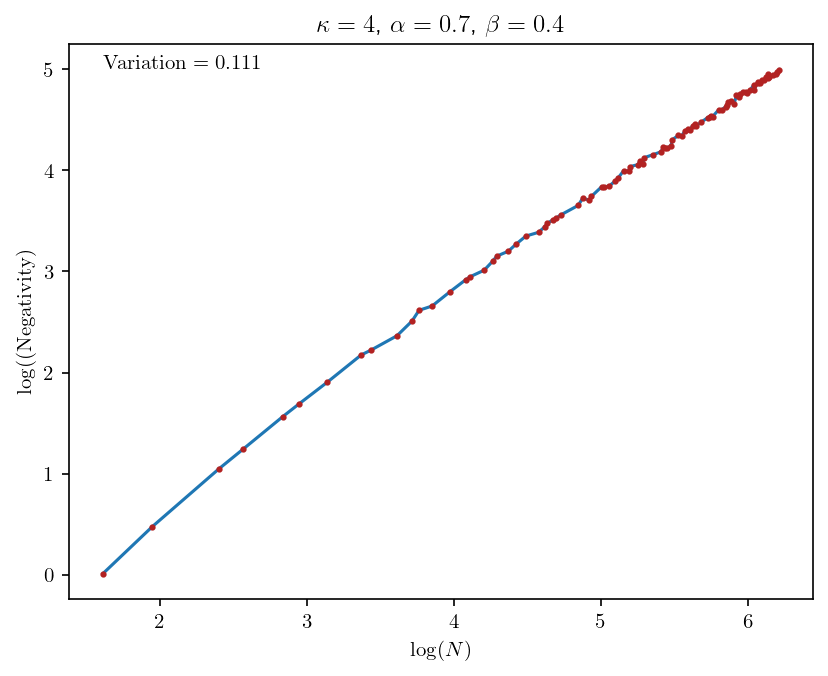

sym pars:  60%|██████    | 3/5 [00:05<00:03,  1.98s/it]

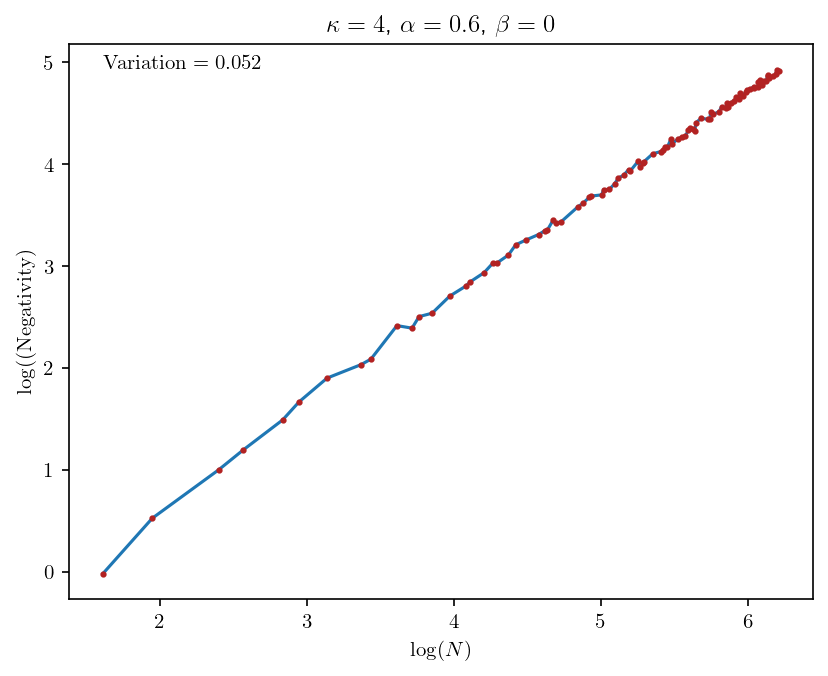

sym pars:  80%|████████  | 4/5 [00:07<00:01,  1.98s/it]

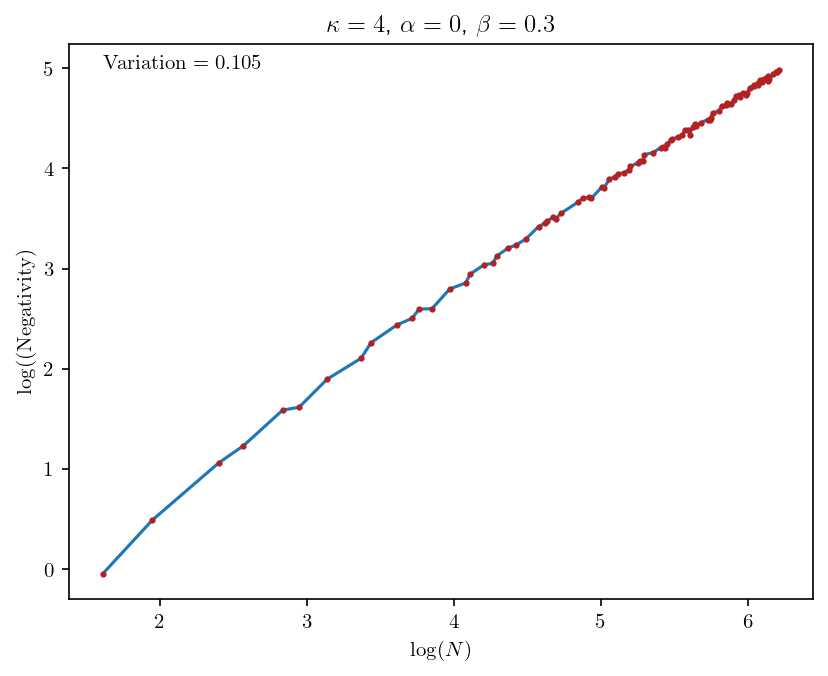

sym pars:   0%|          | 0/5 [00:00<?, ?it/s]        

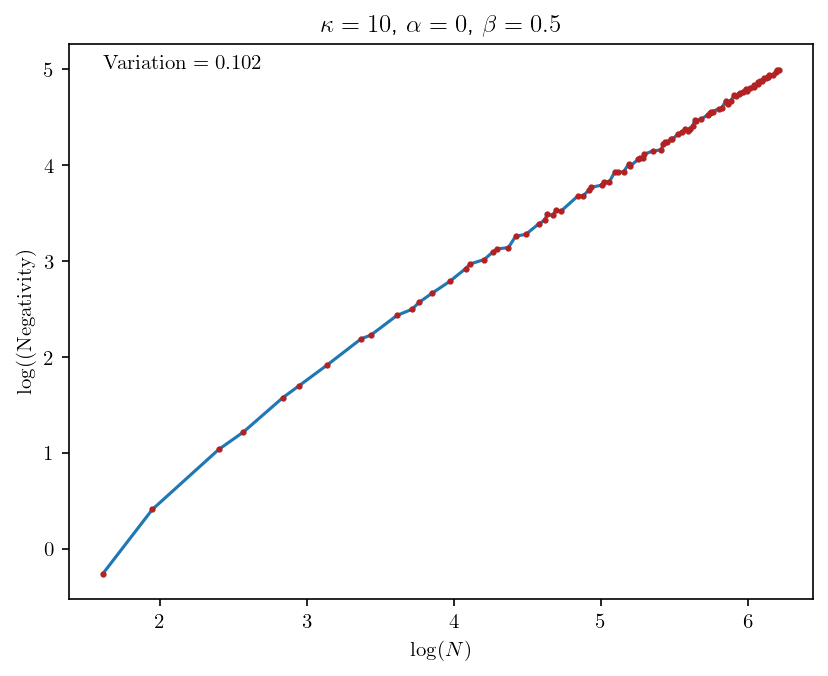

sym pars:  20%|██        | 1/5 [00:02<00:08,  2.12s/it]

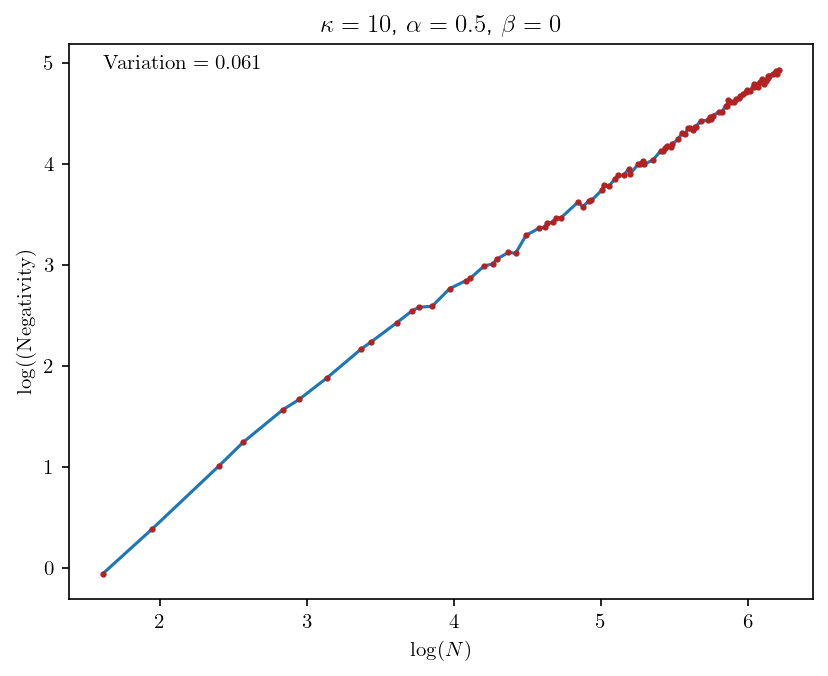

sym pars:  40%|████      | 2/5 [00:04<00:06,  2.12s/it]

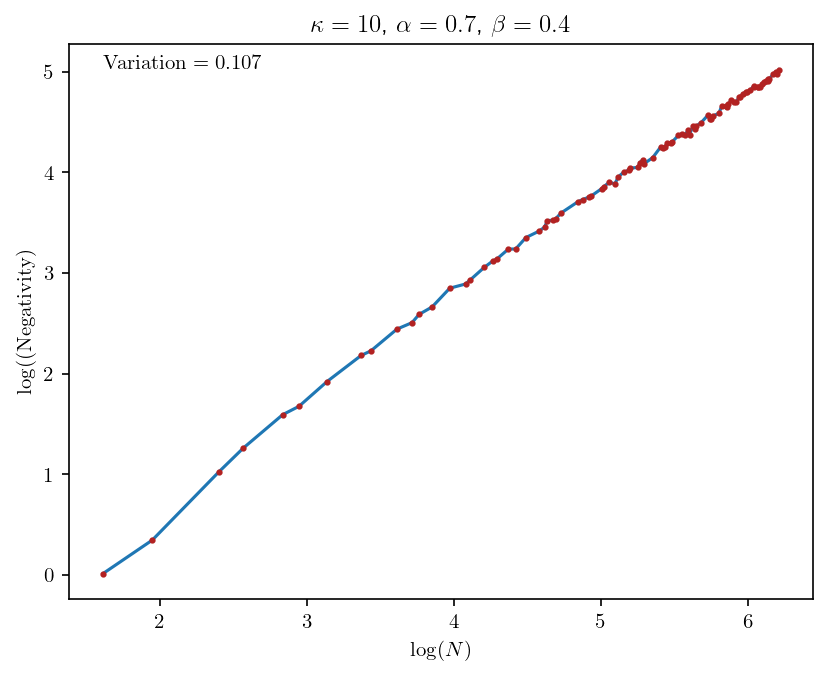

sym pars:  60%|██████    | 3/5 [00:06<00:04,  2.08s/it]

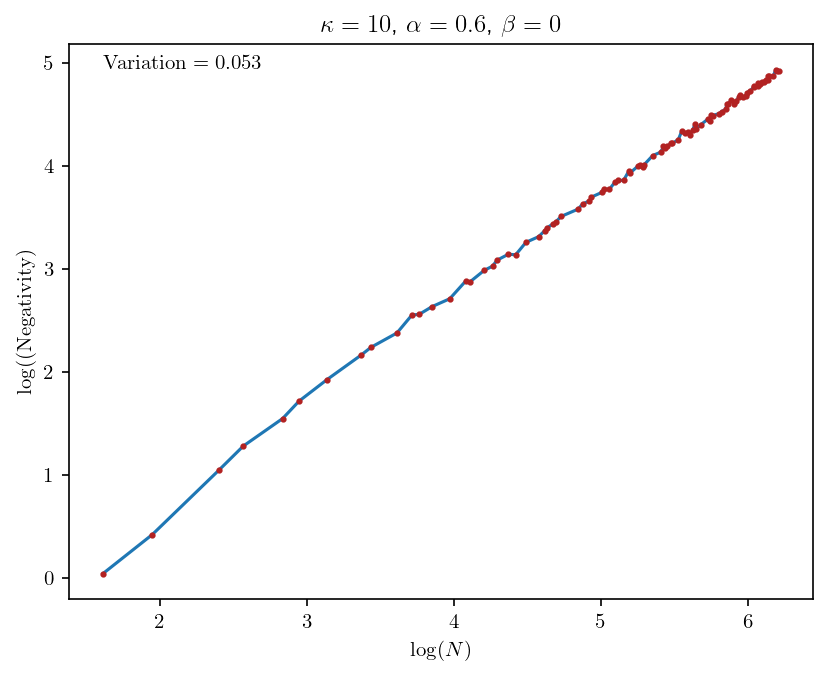

sym pars:  80%|████████  | 4/5 [00:08<00:02,  2.03s/it]

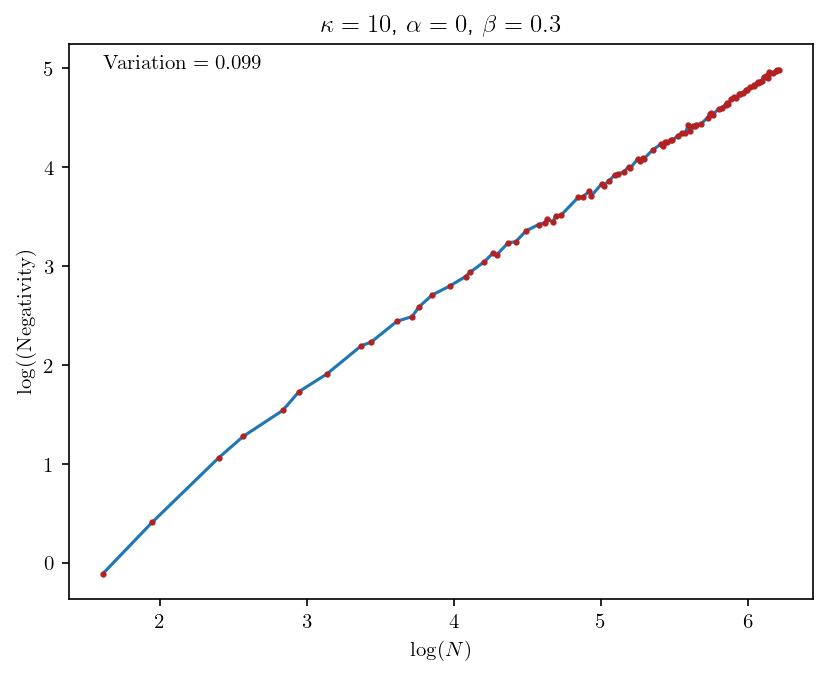

In [13]:
analyze(sizes, K1, symmetry_params, m1, c1, random_state)
analyze(sizes, K2, symmetry_params, m2, c2, random_state)
analyze(sizes, K3, symmetry_params, m3, c3, random_state)

# Coherent state now

In [14]:
neg_coherent1 = system_size_scan(sizes, K1, 0, 0, coherent_state)
neg_coherent2 = system_size_scan(sizes, K2, 0, 0, coherent_state)
neg_coherent3 = system_size_scan(sizes, K3, 0, 0, coherent_state)

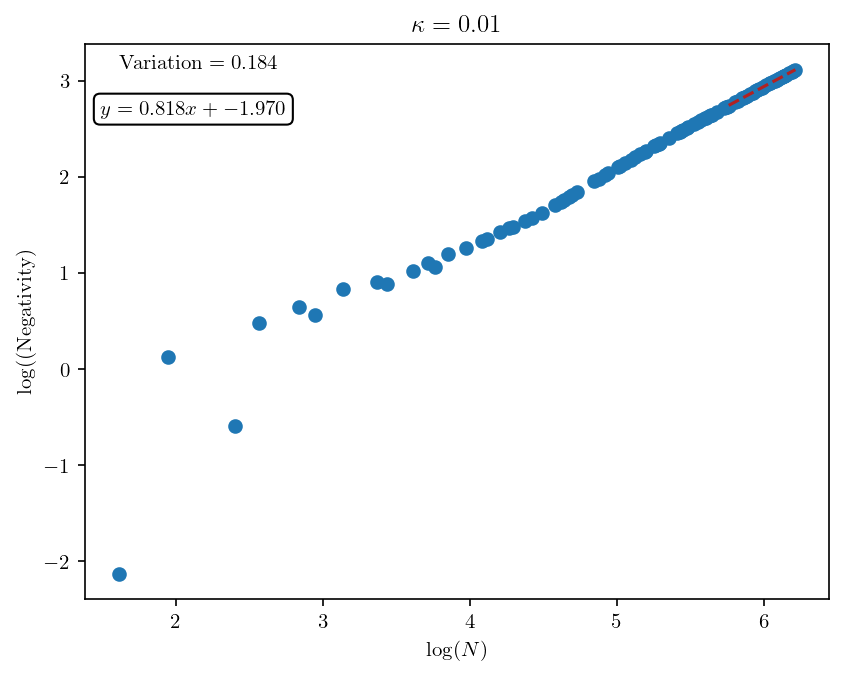

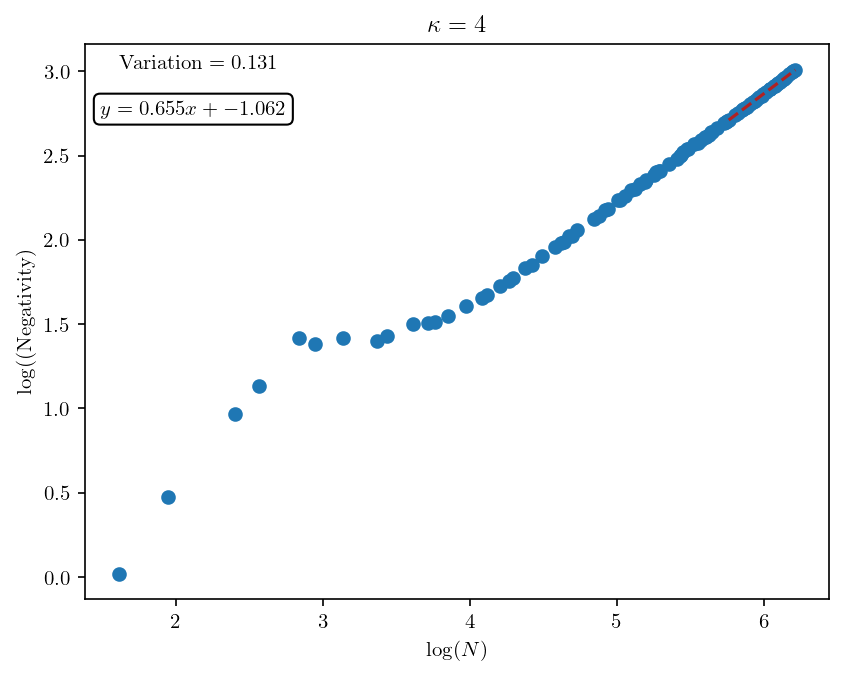

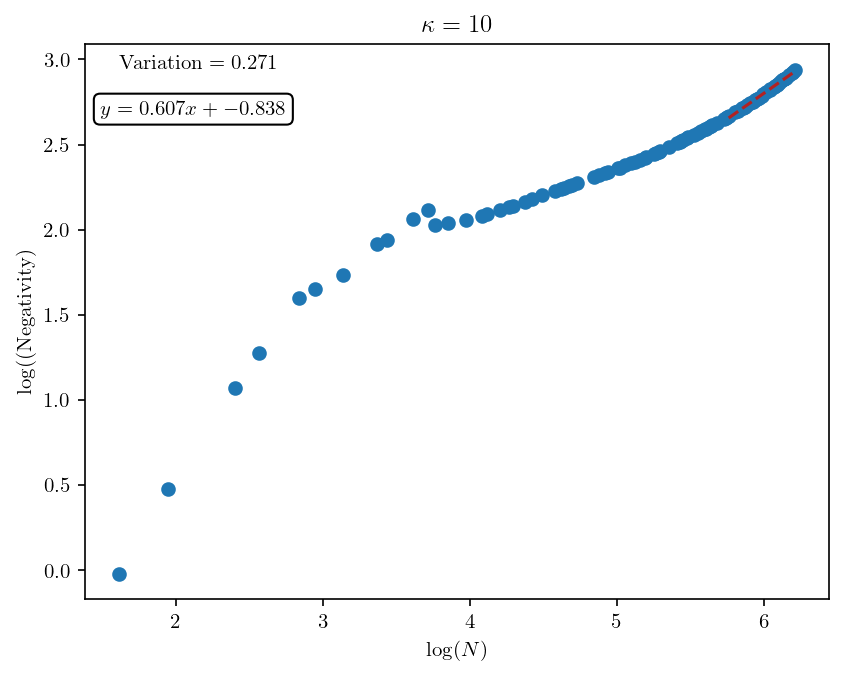

In [15]:
m1, c1 = plot_int_neg(sizes, neg_coherent1, K1)
m2, c2 = plot_int_neg(sizes, neg_coherent2, K2)
m3, c3 = plot_int_neg(sizes, neg_coherent3, K3)

sym pars:   0%|          | 0/5 [00:00<?, ?it/s]

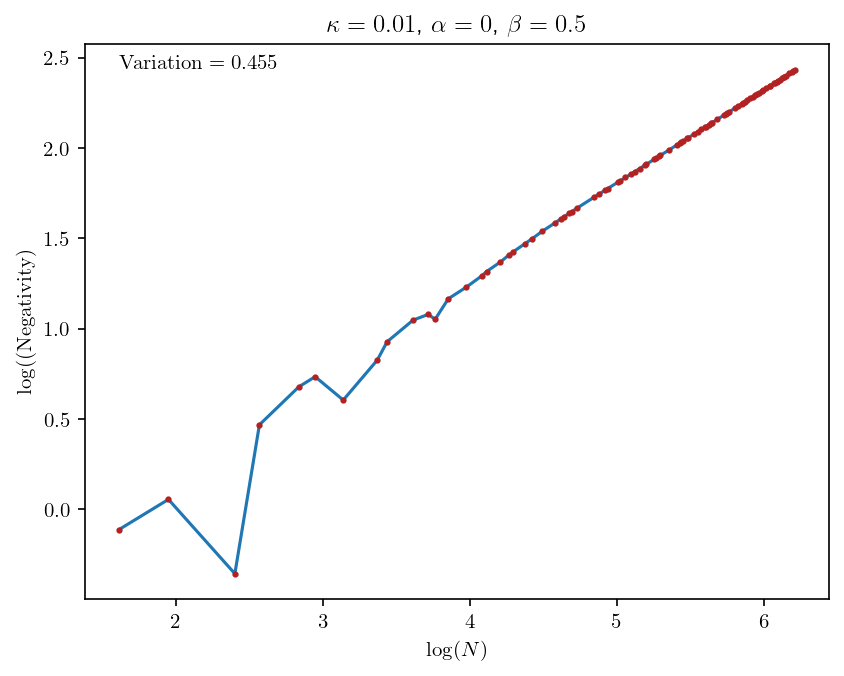

sym pars:  20%|██        | 1/5 [00:03<00:14,  3.52s/it]

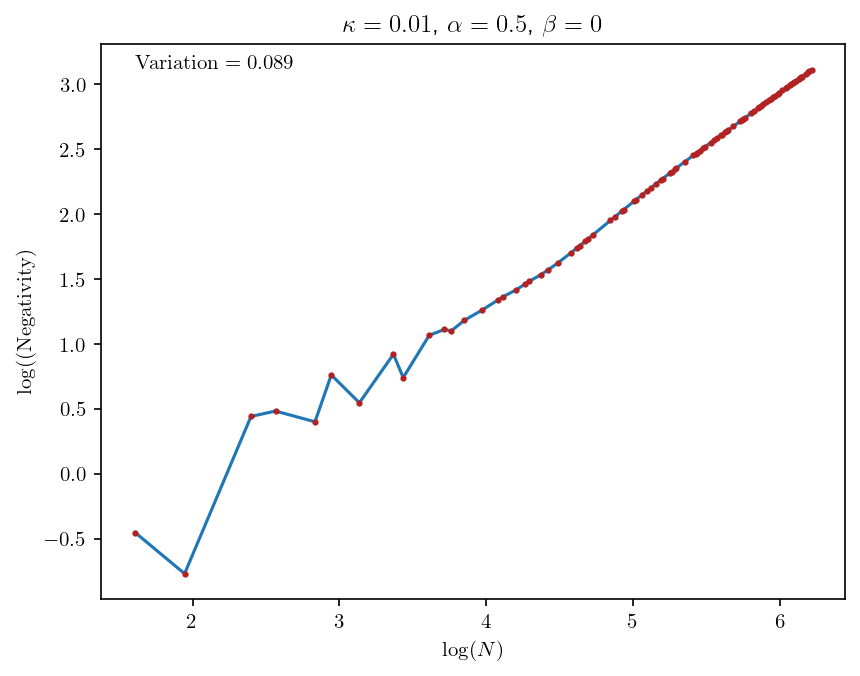

sym pars:  40%|████      | 2/5 [00:06<00:09,  3.27s/it]

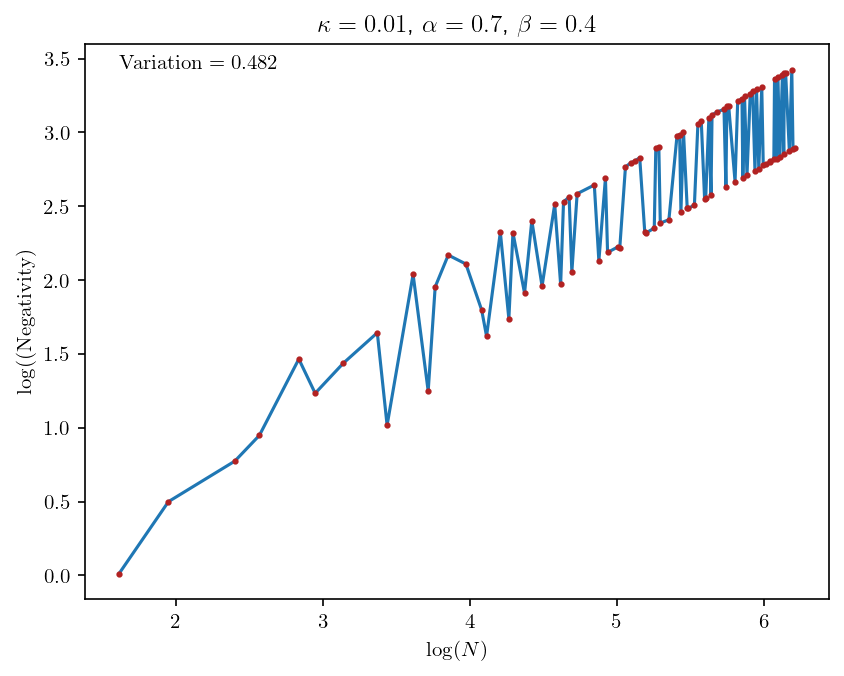

sym pars:  60%|██████    | 3/5 [00:10<00:06,  3.49s/it]

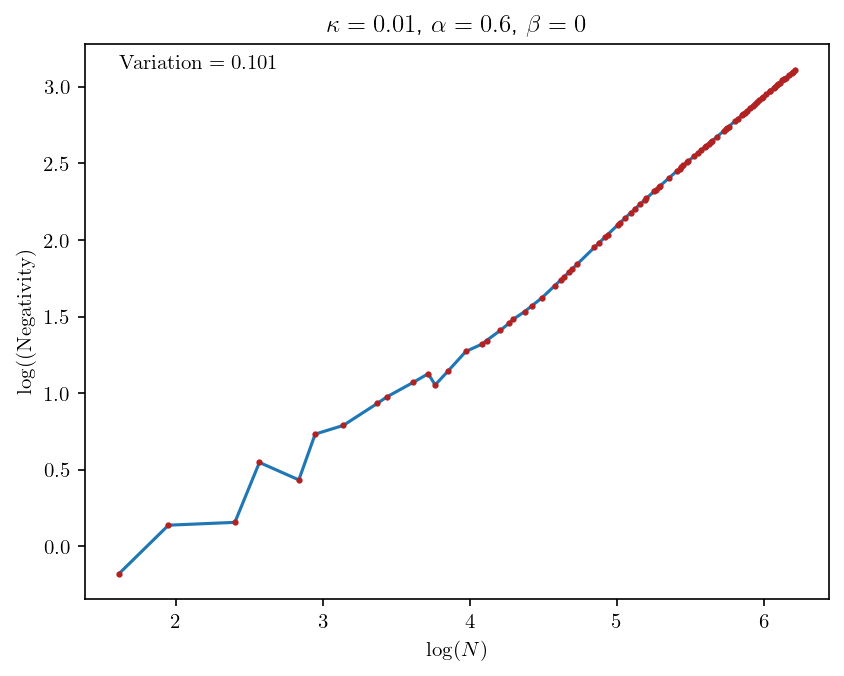

sym pars:  80%|████████  | 4/5 [00:13<00:03,  3.35s/it]

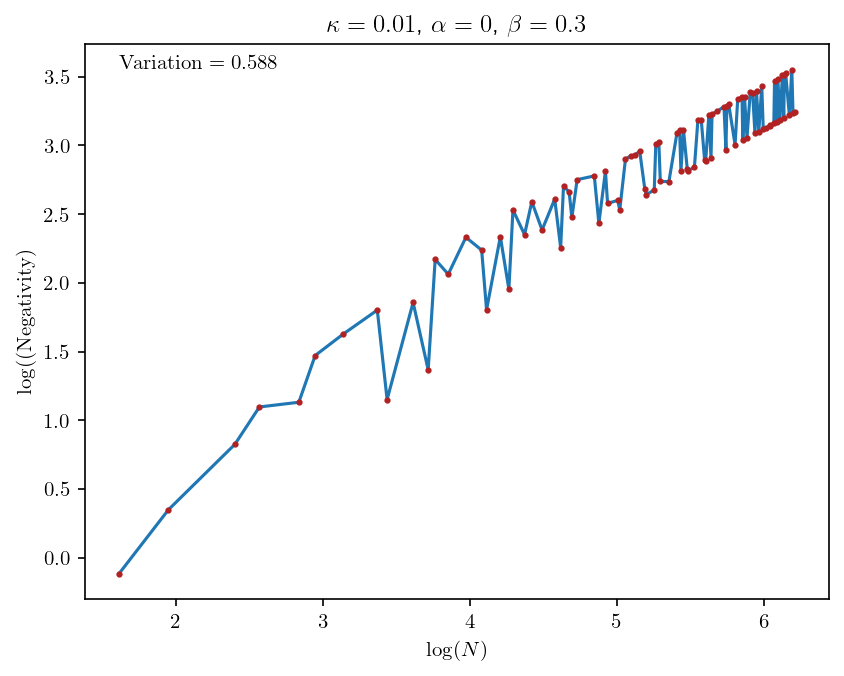

sym pars:   0%|          | 0/5 [00:00<?, ?it/s]        

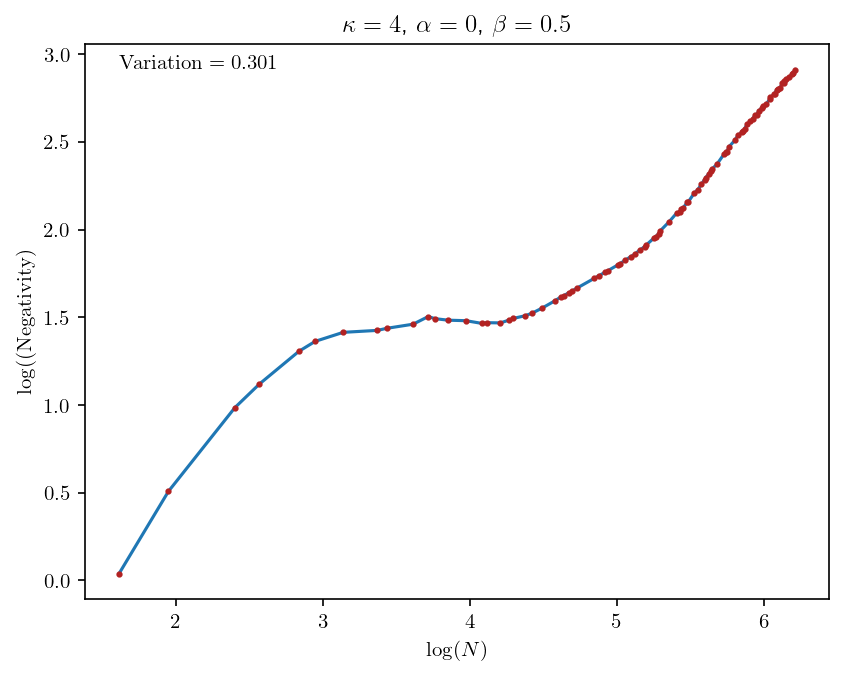

sym pars:  20%|██        | 1/5 [00:03<00:12,  3.24s/it]

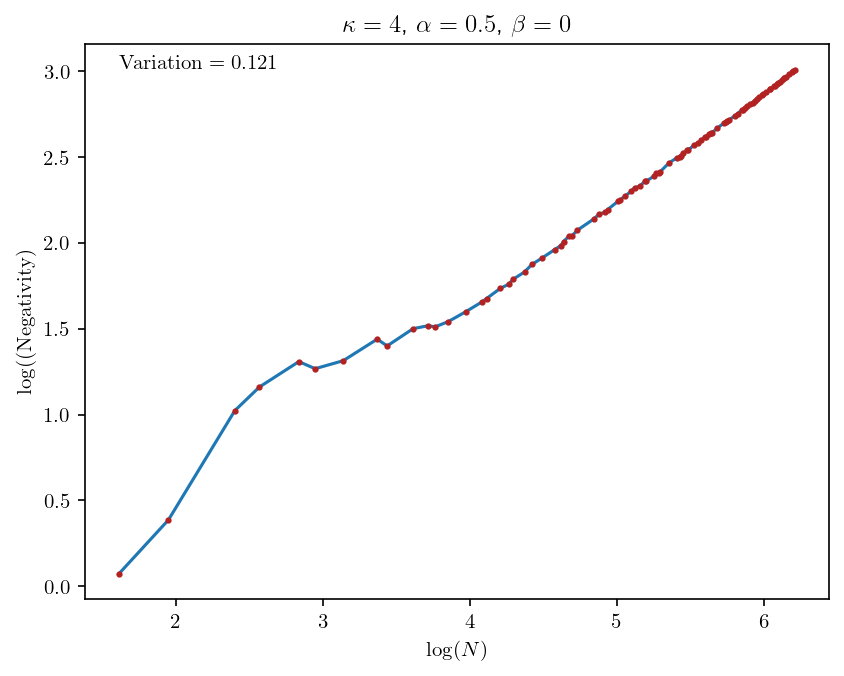

sym pars:  40%|████      | 2/5 [00:06<00:09,  3.19s/it]

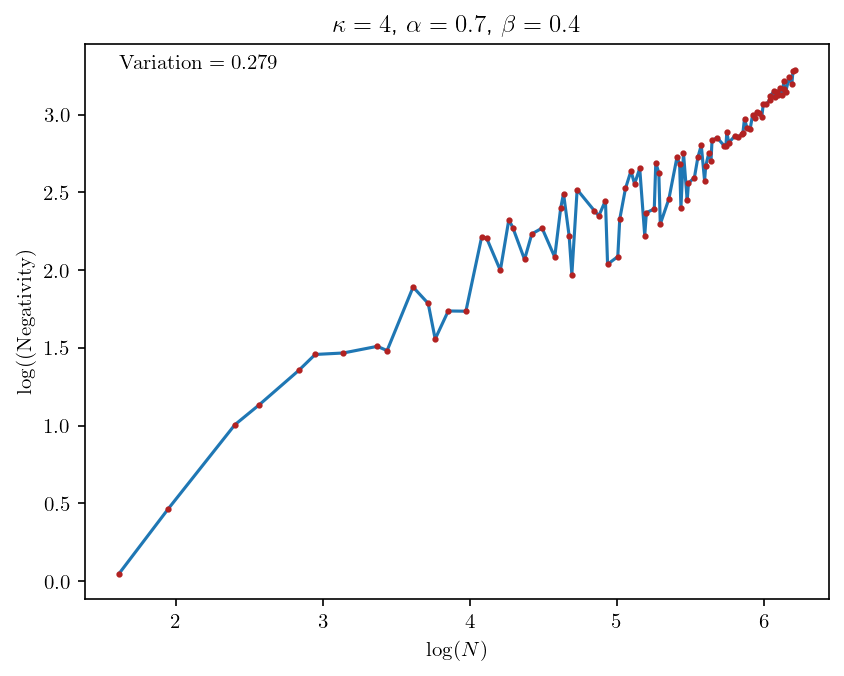

sym pars:  60%|██████    | 3/5 [00:09<00:06,  3.17s/it]

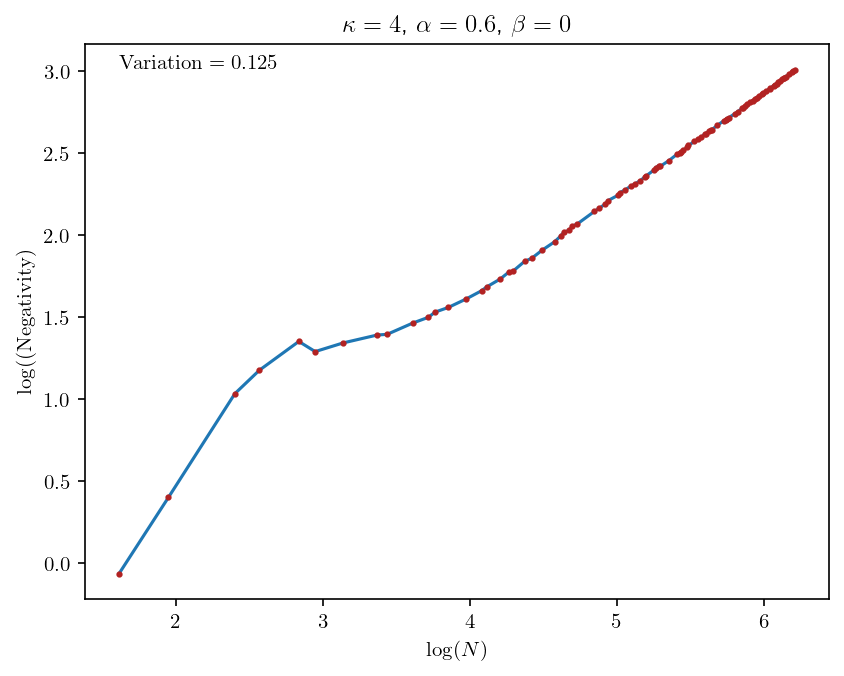

sym pars:  80%|████████  | 4/5 [00:12<00:03,  3.26s/it]

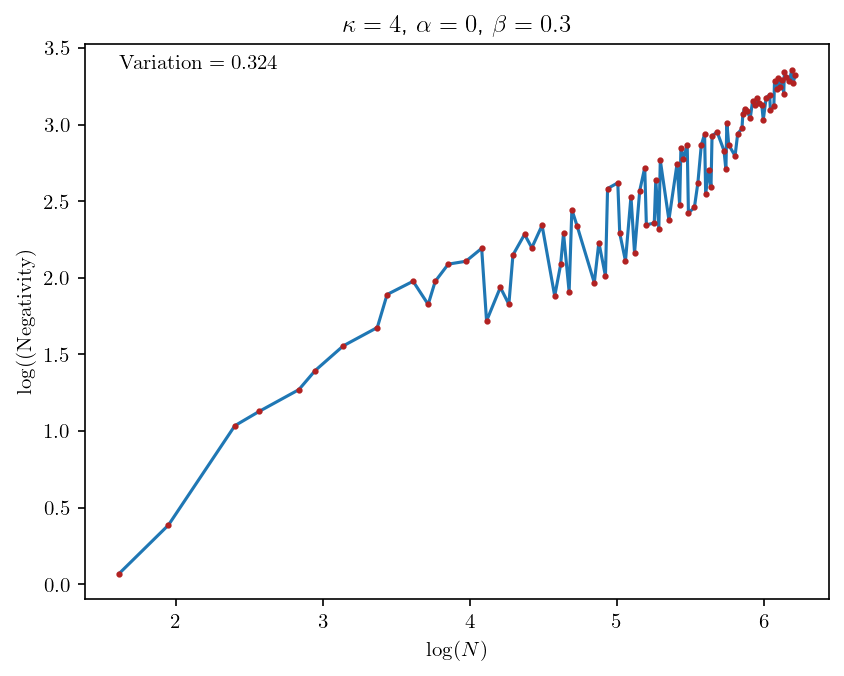

sym pars:   0%|          | 0/5 [00:00<?, ?it/s]        

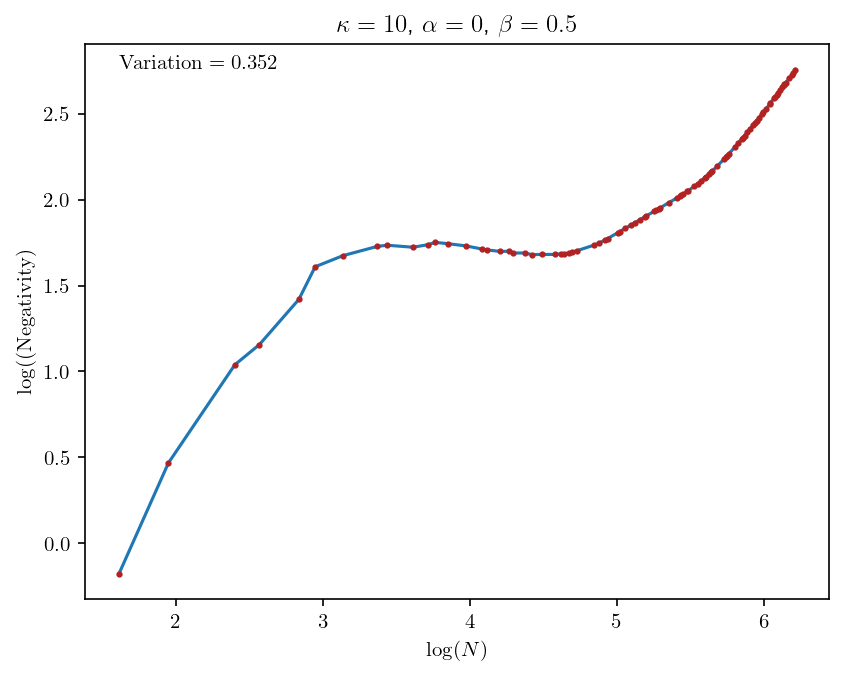

sym pars:  20%|██        | 1/5 [00:03<00:14,  3.74s/it]

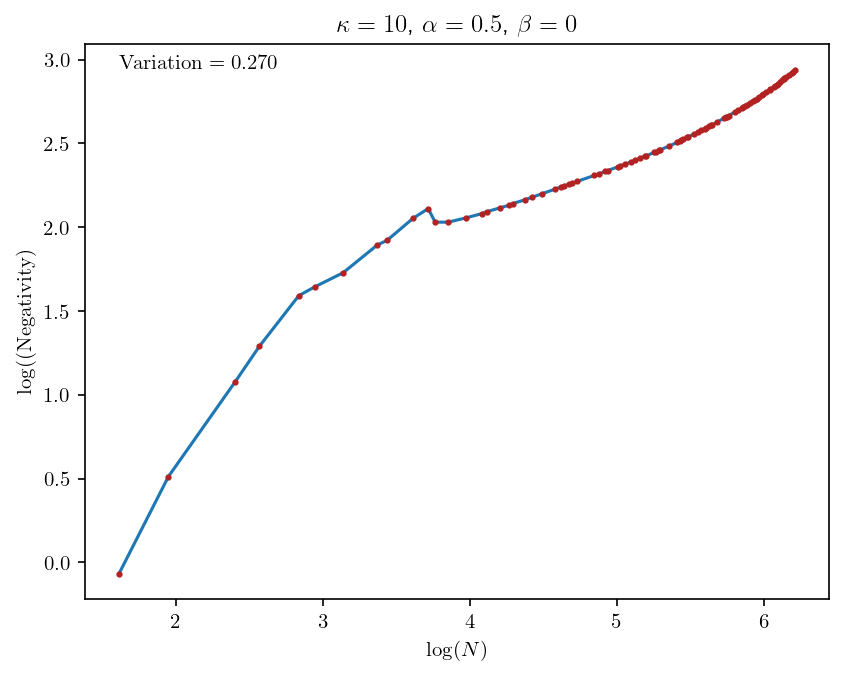

sym pars:  40%|████      | 2/5 [00:07<00:11,  3.67s/it]

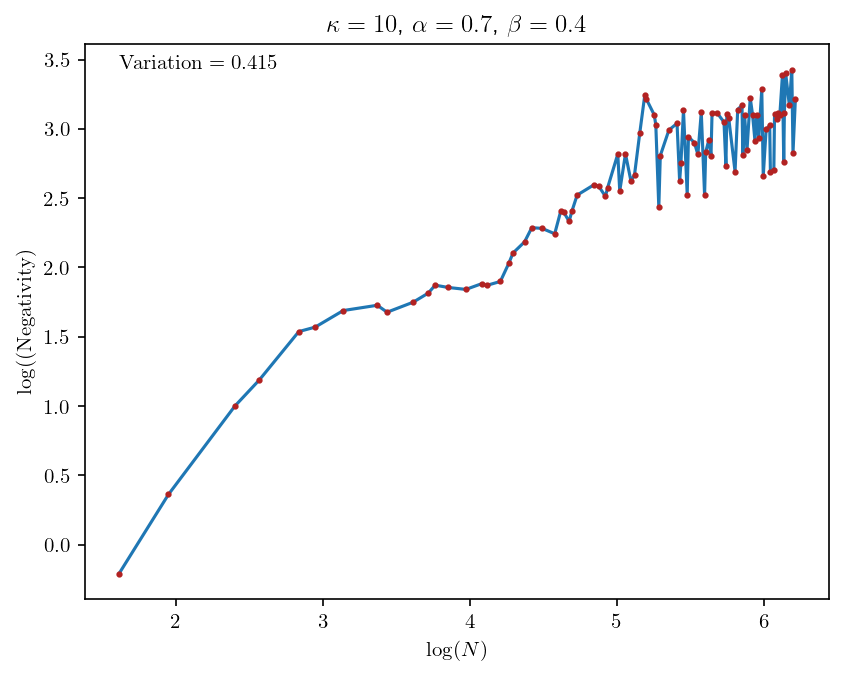

sym pars:  60%|██████    | 3/5 [00:11<00:07,  3.67s/it]

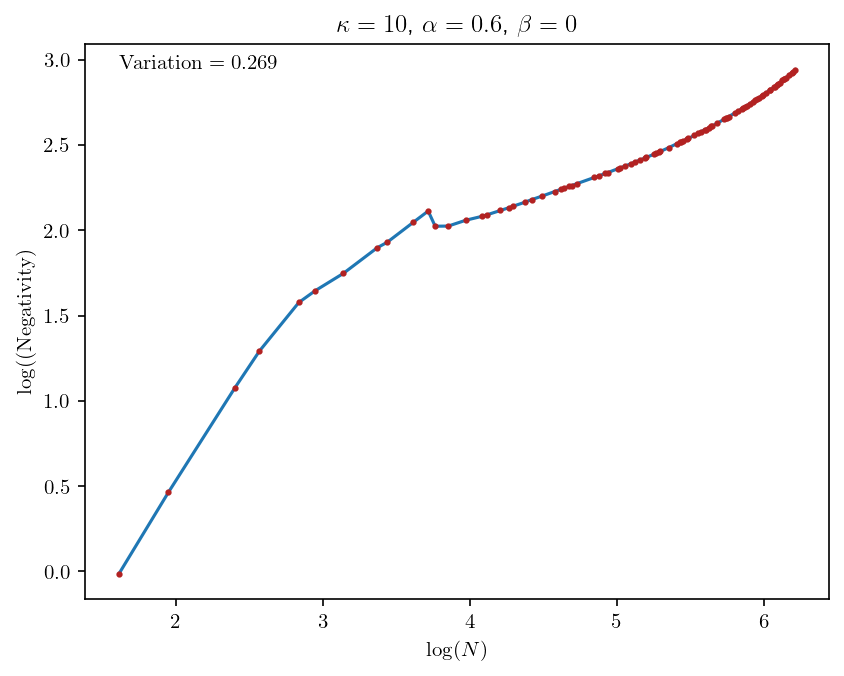

sym pars:  80%|████████  | 4/5 [00:14<00:03,  3.46s/it]

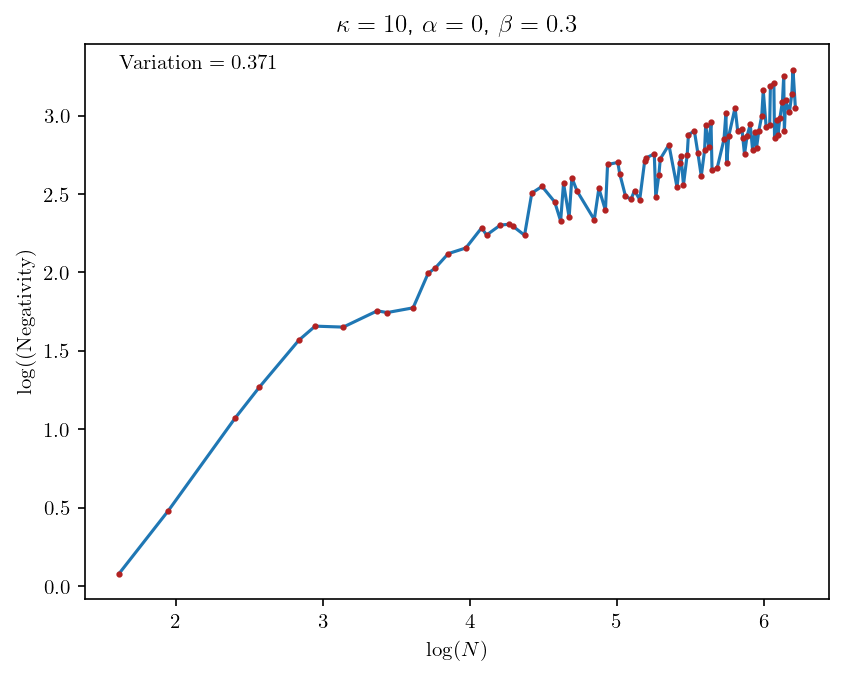

In [16]:
analyze(sizes, K1, symmetry_params, m1, c1, coherent_state)
analyze(sizes, K2, symmetry_params, m2, c2, coherent_state)
analyze(sizes, K3, symmetry_params, m3, c3, coherent_state)

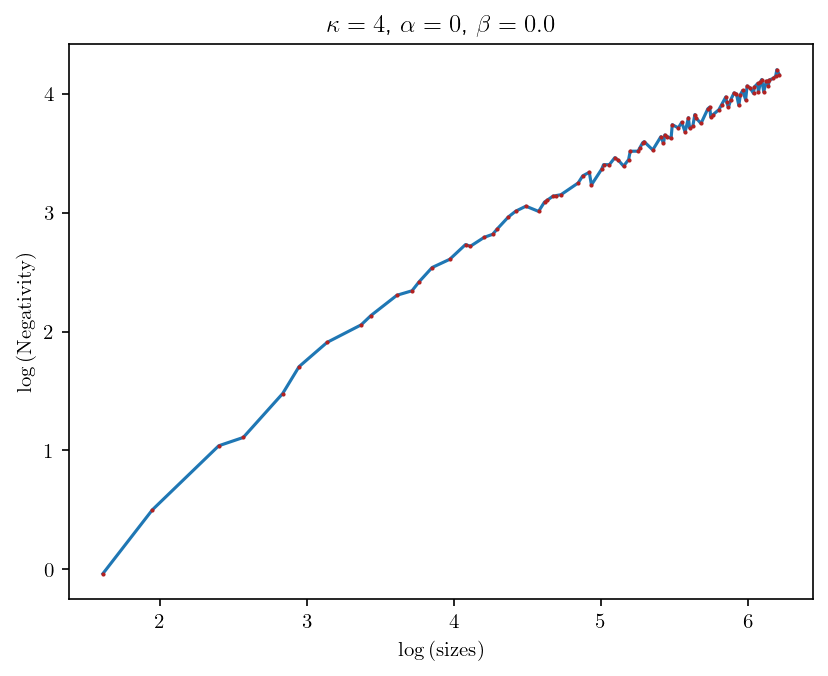

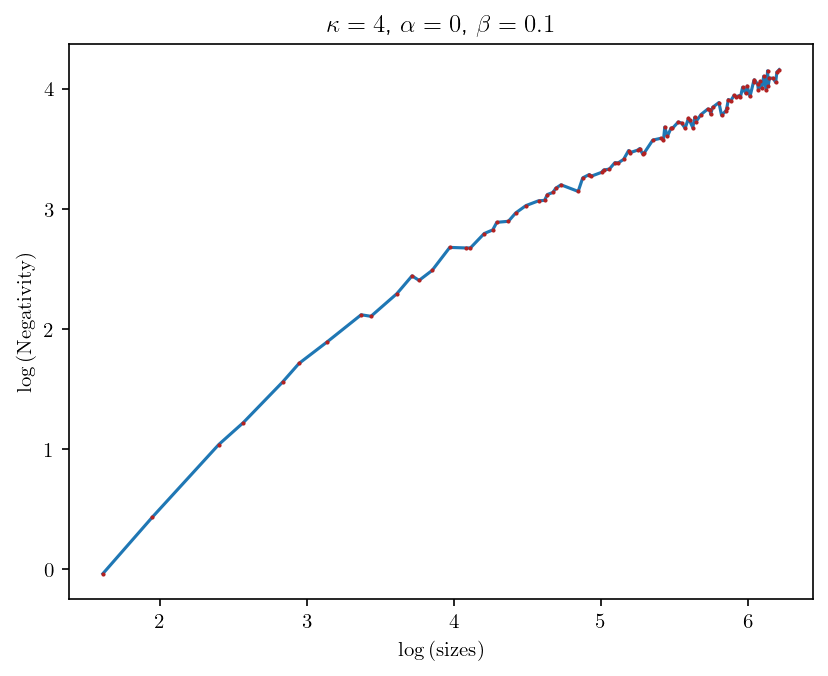

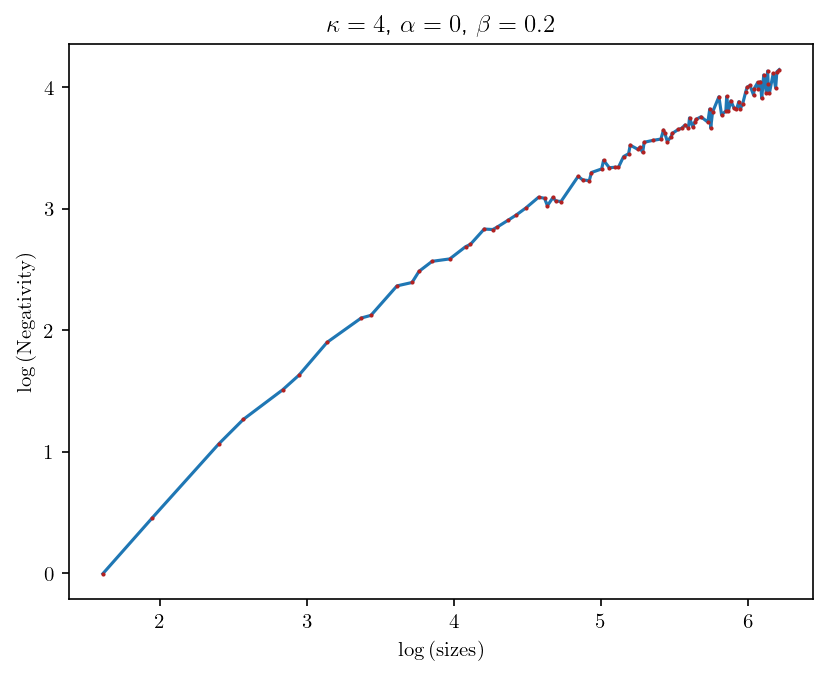

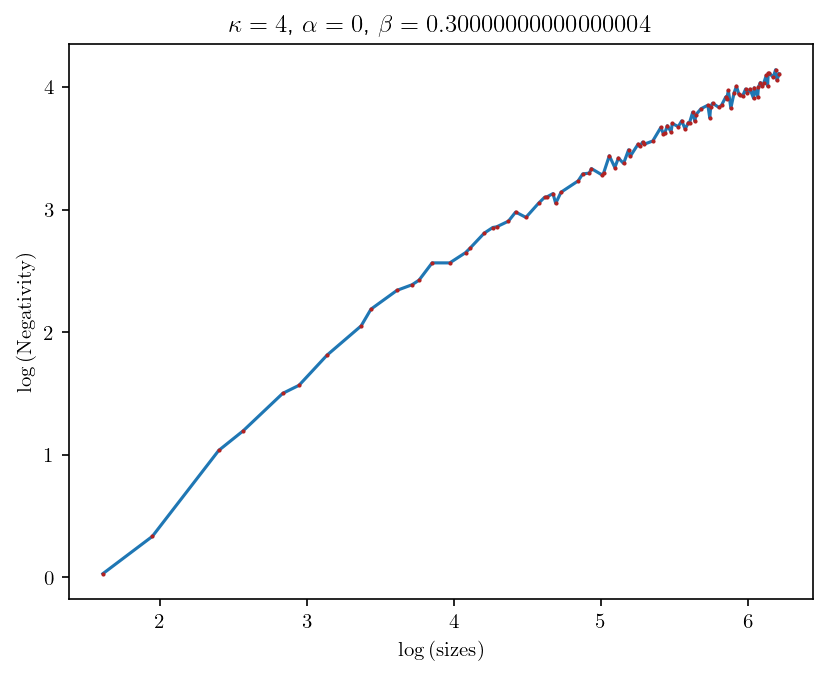

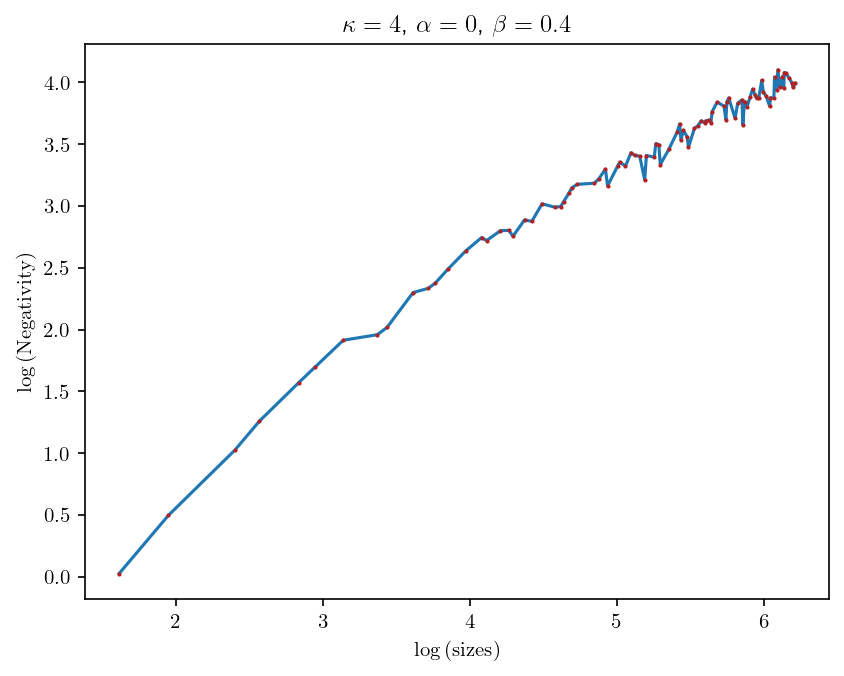

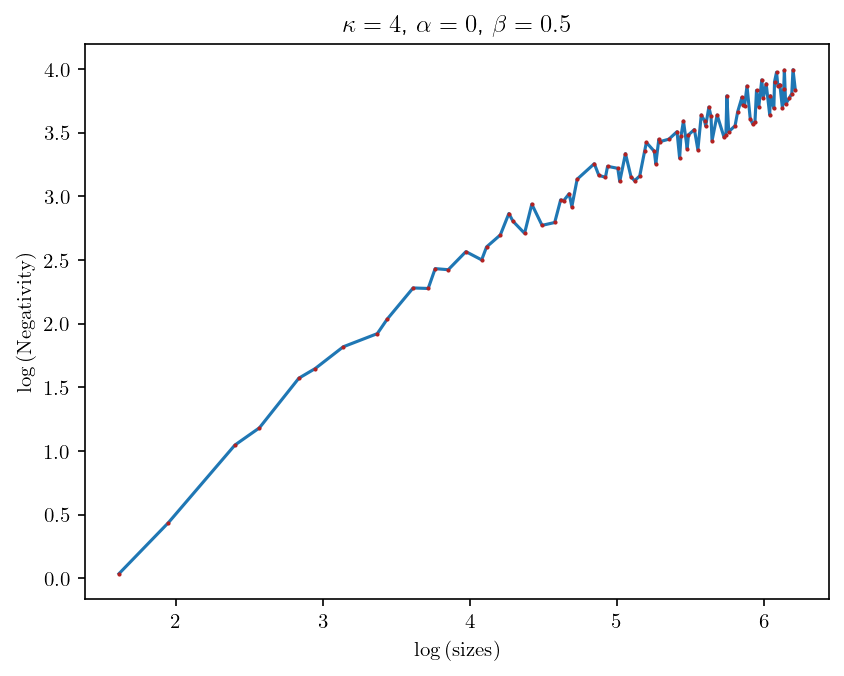

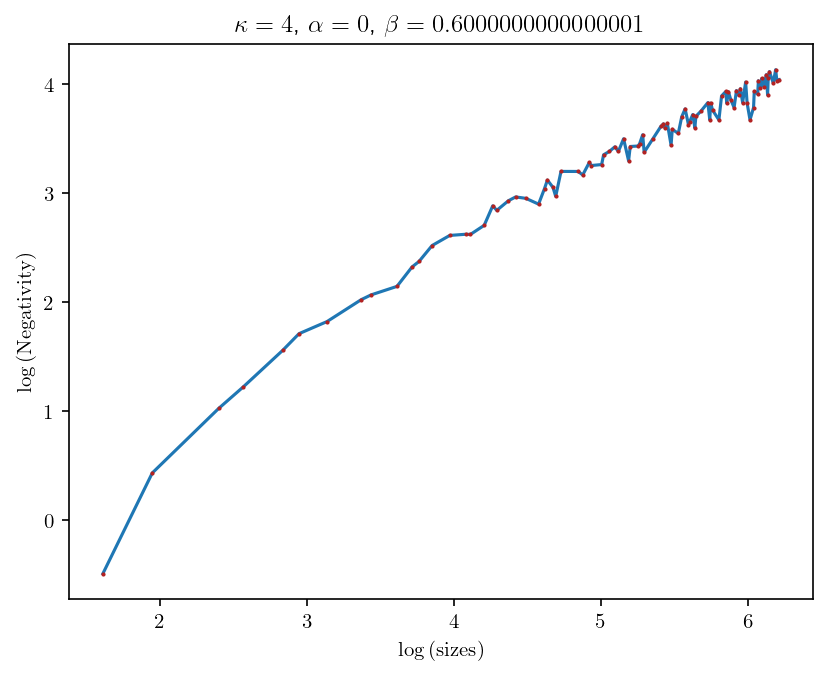

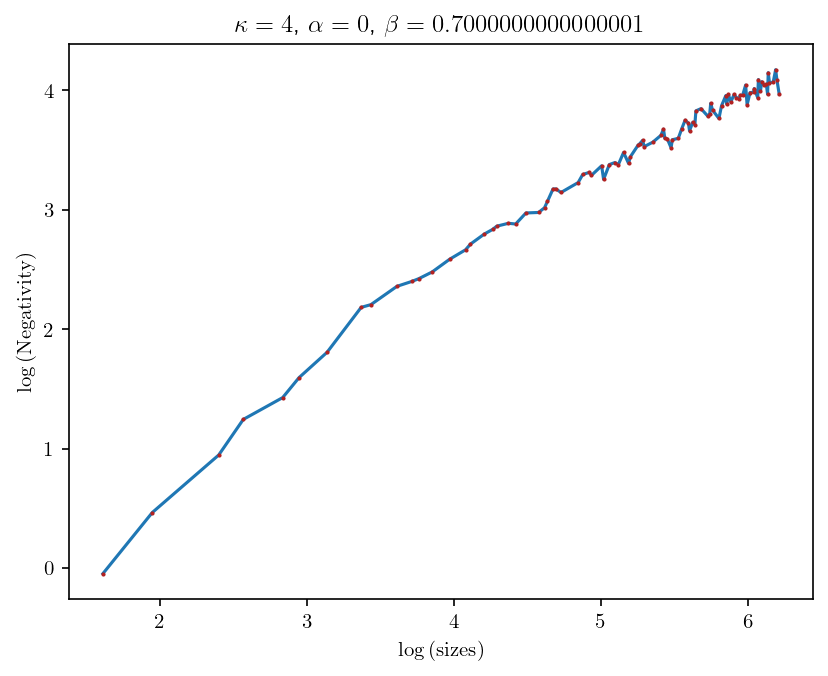

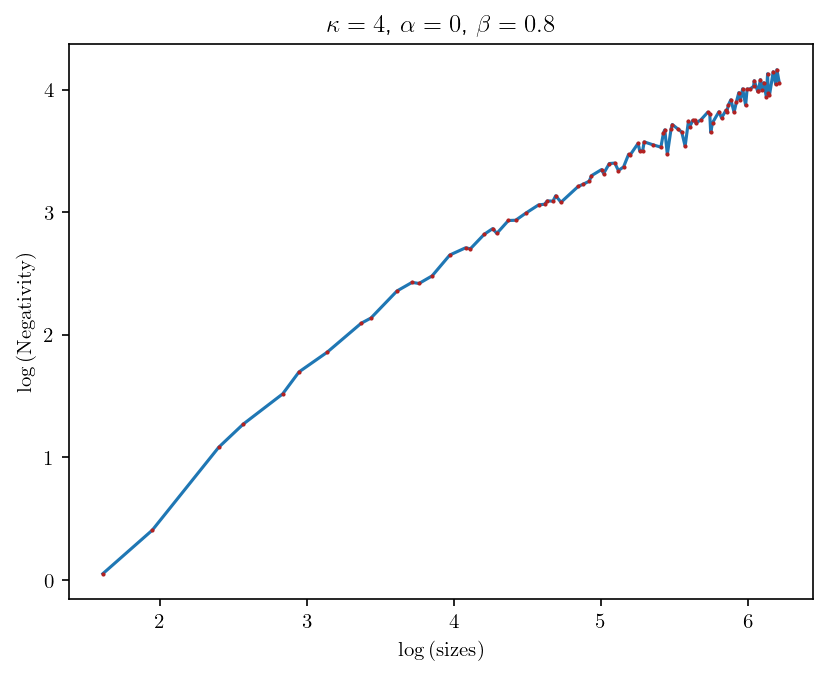

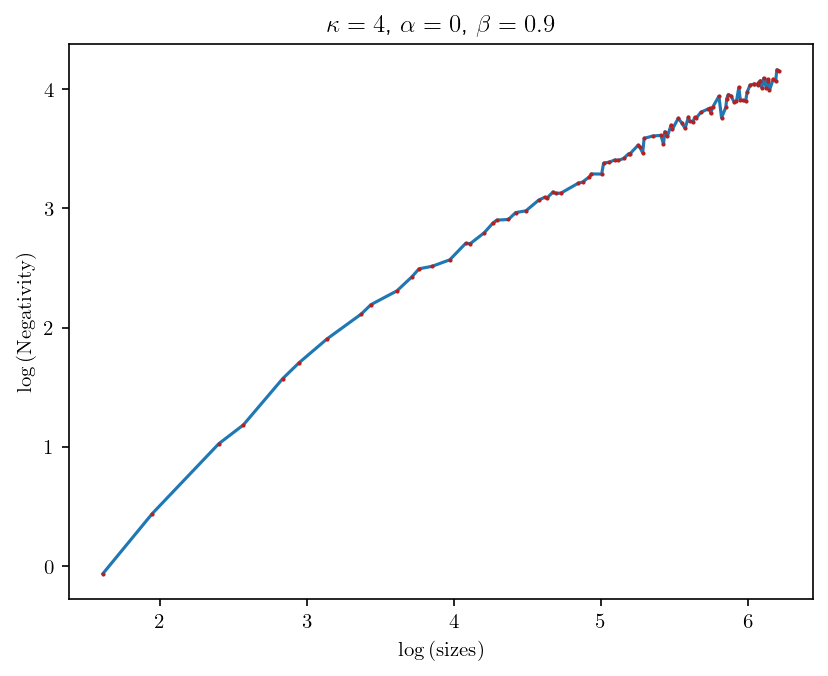

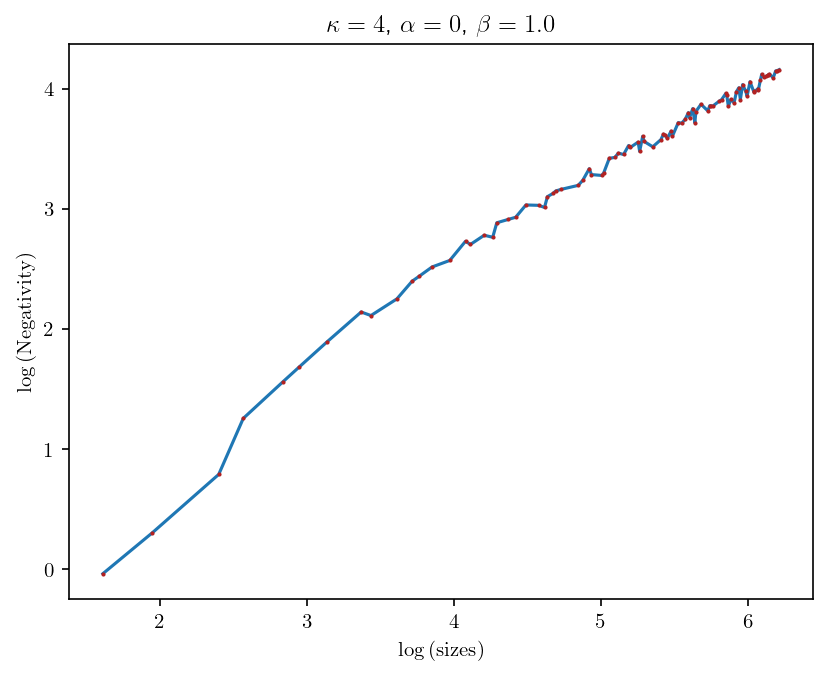

In [17]:
# try for alpha = 0 and beta going higher

betas = np.arange(0, 1.01, 0.1)
for beta in betas:
    neg = system_size_scan(sizes, K2, 0, beta, q_eigenstate)

    plt.plot(np.log(sizes), np.log(neg), marker = 'o', markersize = 1, markerfacecolor = 'firebrick', markeredgecolor = 'firebrick')
    plt.xlabel(rf"$\log{{(\mathrm{{sizes}})}}$")
    plt.ylabel(rf"$\log{{(\mathrm{{Negativity}})}}$")
    plt.title(rf"$\kappa = {K2}$, $\alpha = {0}$, $\beta = {beta}$")
    plt.show()